#FedFCA : Federated Formal Concept Analysis Framework

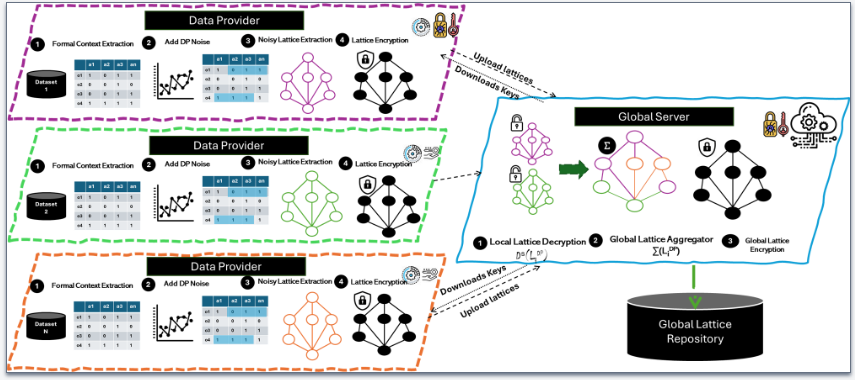

# Install Required Librairies


In [10]:
pip install seaborn  dash dash-bootstrap-components flask-ngrok cryptography tenseal psutil

# Splitting and Saving Formal Context Data for Federated Providers
###   Description:
This section focuses on splitting a global formal context dataset into smaller subsets for multiple federated providers. The splitting respects the principles of IID (Independent and Identically Distributed) and Non-IID (Dirichlet-based) distributions.

Each provider receives a unique subset of objects with their corresponding attributes, ensuring attribute distribution aligns with the global dataset parameters. The generated subsets are saved in a structured format (.txt or .json), maintaining consistency and usability for federated learning or further analysis. The implementation ensures:

- Correct mapping of objects to providers.
- Proper distribution of attributes across providers.
- File generation in a format suitable for downstream tasks.

In [12]:
import numpy as np
import os
import random
import shutil
import requests
from typing import Dict, List, Set
from scipy.stats import dirichlet

# Utility Functions
def download_file(url, filename=None):
    """Downloads a file from a URL and saves it locally."""
    try:
        if filename is None:
            filename = os.path.basename(url)

        response = requests.get(url, stream=True)
        response.raise_for_status()

        with open(filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

        print(f"File downloaded successfully: {filename}")
        return filename
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        return None


def process_fimi_dataset(input_file):
    """Processes the FIMI dataset into a formal context (dict format)."""
    formatted_data = []
    with open(input_file, 'r') as file:
        for line in file:
            attributes = list(map(int, line.strip().split()))
            formatted_data.append(attributes)

    # Convert to formal context: {object_id: {attributes}}
    formal_context_dict = {}
    for obj_idx, attributes in enumerate(formatted_data, start=1):
        formal_context_dict[obj_idx] = set(attributes)

    return formal_context_dict


def save_formal_context(formal_context_dict, filename):
    """Saves the formal context to a file."""
    with open(filename, 'w') as file:
        for obj_idx, attributes in formal_context_dict.items():
            file.write(f"{obj_idx}: {sorted(attributes)}\n")
    print(f"Formal context saved to {filename}")


# Core Partitioning Function
def split_dataset_into_providers_fca(
    formal_context_dict: Dict[int, Set[int]],
    num_providers: int,
    splitting_type: str = "IID",
    skew_factor: float = 1.0,
    attribute_distribution_skew: bool = False,
    quantity_skew: bool = False,
    max_objects_per_provider: int = None,
):
    """
    Enhanced splitting of formal contexts for FCA in federated learning.
    Addresses empty providers and imbalanced distributions.
    """
    num_objects = len(formal_context_dict)
    object_ids = np.array(list(formal_context_dict.keys()))
    all_attributes = list({attr for attrs in formal_context_dict.values() for attr in attrs})

    if splitting_type == "IID":
        # Equal distribution of objects
        shuffled_indices = np.random.permutation(object_ids)
        provider_indices = np.array_split(shuffled_indices, num_providers)

    elif splitting_type == "Non-IID":
        provider_indices = [[] for _ in range(num_providers)]

        if attribute_distribution_skew:
            # Attribute-based skew
            attribute_proportions = dirichlet.rvs([skew_factor] * num_providers, size=len(all_attributes))

            for obj_idx, attributes in formal_context_dict.items():
                provider_weights = np.zeros(num_providers)
                for attr in attributes:
                    if attr in all_attributes:
                        attr_idx = all_attributes.index(attr)
                        provider_weights += attribute_proportions[attr_idx]

                # Probabilistic assignment instead of argmax
                provider_choice = np.random.choice(
                    range(num_providers),
                    p=provider_weights / provider_weights.sum()
                )
                provider_indices[provider_choice].append(obj_idx)

        elif quantity_skew:
            # Quantity skew
            proportions = dirichlet.rvs([skew_factor] * num_providers, size=1)[0]
            shuffled_object_ids = np.random.permutation(object_ids)

            for obj_idx in shuffled_object_ids:
                provider_choice = np.random.choice(num_providers, p=proportions)
                if max_objects_per_provider is not None and len(provider_indices[provider_choice]) >= max_objects_per_provider:
                    available_providers = [i for i in range(num_providers) if len(provider_indices[i]) < max_objects_per_provider]
                    if available_providers:
                        provider_choice = np.random.choice(available_providers)
                    else:
                        break
                provider_indices[provider_choice].append(obj_idx)

        # Redistribute objects to empty providers
        for provider_idx, indices in enumerate(provider_indices):
            if not indices:
                fullest_provider = max(range(num_providers), key=lambda x: len(provider_indices[x]))
                provider_indices[provider_idx].append(provider_indices[fullest_provider].pop())

    else:
        raise ValueError(f"Unknown splitting_type: {splitting_type}")

    # Create provider datasets
    provider_data = []
    for indices in provider_indices:
        provider_dict = {
            obj_idx: formal_context_dict.get(obj_idx)
            for obj_idx in indices
            if obj_idx in formal_context_dict
        }
        if provider_dict:
            provider_data.append(provider_dict)
        else:
            print(f"Warning: Empty provider detected.")

    # Validate total distribution
    total_assigned_objects = sum(len(provider) for provider in provider_data)
    if total_assigned_objects != num_objects:
        raise ValueError("Mismatch in total objects distributed among providers.")

    return provider_data


# Save Provider Data
def save_provider_data(dataset_name, num_providers, provider_idx, provider_data, splitting_type):
    """
    Saves provider-specific data in the required format.
    Example format:
    1: {1, 5, 6, 11, 13, 15, 18, 22, 24, 27}
    """
    provider_folder = os.path.join(dataset_name, str(num_providers), splitting_type)
    os.makedirs(provider_folder, exist_ok=True)
    provider_filename = os.path.join(provider_folder, f"provider_{provider_idx}.txt")
    with open(provider_filename, 'w') as file:
        for obj_idx, attributes in provider_data.items():
            # Write attributes as a set
            file.write(f"{obj_idx}: {attributes}\n")
    print(f"Provider {provider_idx} data saved to {provider_filename}")



# Create Federated Datasets
def create_federated_datasets(
    dataset_urls,
    num_providers_list,
    splitting_types,
    skew_factor=1.0,
    attribute_distribution_skew=False,
    quantity_skew=False,
    max_objects_per_provider=None,
):
    """Generates federated datasets with IID and Non-IID partitioning."""
    for dataset_name, url in dataset_urls.items():
        print(f"Fetching {dataset_name} dataset...")
        input_file = f"{dataset_name}.dat"
        if not os.path.exists(input_file):
            downloaded_file = download_file(url, input_file)
            if not downloaded_file:
                print(f"Failed to download {dataset_name}. Please download it manually.")
                continue

        formal_context_dict = process_fimi_dataset(input_file)
        if os.path.exists(dataset_name):
            shutil.rmtree(dataset_name)
        os.makedirs(dataset_name, exist_ok=True)

        save_formal_context(formal_context_dict, os.path.join(dataset_name, f"{dataset_name}.data"))

        for num_providers in num_providers_list:
            for splitting_type in splitting_types:
                provider_data_list = split_dataset_into_providers_fca(
                    formal_context_dict,
                    num_providers,
                    splitting_type,
                    skew_factor,
                    attribute_distribution_skew,
                    quantity_skew,
                    max_objects_per_provider,
                )

                for provider_idx, provider_data in enumerate(provider_data_list, start=1):
                    save_provider_data(dataset_name, num_providers, provider_idx, provider_data, splitting_type)


# Example Usage
dataset_urls = {
    "mushroom" : "http://fimi.uantwerpen.be/data/mushroom.dat",
    "chess" : "http://fimi.uantwerpen.be/data/chess.dat",
    "Skin": "https://raw.githubusercontent.com/msellamiTN/fedfca-framework/refs/heads/main/data/fimi/Skin.dat",
    "RecordLink": "https://raw.githubusercontent.com/msellamiTN/fedfca-framework/refs/heads/main/data/fimi/RecordLink.dat",
    "connect": "http://fimi.uantwerpen.be/data/connect.dat",
    "T10I4D100K": "http://fimi.uantwerpen.be/data/T10I4D100K.dat",
}
num_providers_list = [50, 100,150,200,250]
splitting_types = ["IID", "Non-IID"]
skew_factor = 0.2
max_objects_per_provider = 1000

create_federated_datasets(
    dataset_urls=dataset_urls,
    num_providers_list=num_providers_list,
    splitting_types=splitting_types,
    skew_factor=skew_factor,
    attribute_distribution_skew=True,
    quantity_skew=True,
    max_objects_per_provider=max_objects_per_provider,
)


Fetching mushroom dataset...
Formal context saved to mushroom/mushroom.data
Provider 1 data saved to mushroom/50/IID/provider_1.txt
Provider 2 data saved to mushroom/50/IID/provider_2.txt
Provider 3 data saved to mushroom/50/IID/provider_3.txt
Provider 4 data saved to mushroom/50/IID/provider_4.txt
Provider 5 data saved to mushroom/50/IID/provider_5.txt
Provider 6 data saved to mushroom/50/IID/provider_6.txt
Provider 7 data saved to mushroom/50/IID/provider_7.txt
Provider 8 data saved to mushroom/50/IID/provider_8.txt
Provider 9 data saved to mushroom/50/IID/provider_9.txt
Provider 10 data saved to mushroom/50/IID/provider_10.txt
Provider 11 data saved to mushroom/50/IID/provider_11.txt
Provider 12 data saved to mushroom/50/IID/provider_12.txt
Provider 13 data saved to mushroom/50/IID/provider_13.txt
Provider 14 data saved to mushroom/50/IID/provider_14.txt
Provider 15 data saved to mushroom/50/IID/provider_15.txt
Provider 16 data saved to mushroom/50/IID/provider_16.txt
Provider 17 da

In [13]:
!wget --trust-server-names --content-disposition "https://www.philippe-fournier-viger.com/spmf/datasets/Skin.txt"


--2026-02-26 21:22:22--  https://www.philippe-fournier-viger.com/spmf/datasets/Skin.txt
Resolving www.philippe-fournier-viger.com (www.philippe-fournier-viger.com)... 104.21.16.70, 172.67.166.227, 2606:4700:3031::ac43:a6e3, ...
Connecting to www.philippe-fournier-viger.com (www.philippe-fournier-viger.com)|104.21.16.70|:443... connected.
HTTP request sent, awaiting response... 300 Multiple Choices
Length: unspecified [text/html]
Saving to: ‘Skin.txt.1’

Skin.txt.1              [ <=>                ]     500  --.-KB/s    in 0s      

2026-02-26 21:22:22 (100 MB/s) - ‘Skin.txt.1’ saved [500]



# Synthetic Data Generation

In [14]:
import numpy as np
import os
import random
import shutil
from typing import List, Tuple, Union
import logging
def generate_formal_context(num_objects, num_attributes, density=0.3, noise_level=0.0, attribute_correlation=0.5):
    """
    Generate a formal context with enhanced generation capabilities, ensuring stability for minimal generators.
    Ensures each object has at least 2 attributes and respects the density.
    """
    if not (0 <= density <= 1):
        raise ValueError("Density must be between 0 and 1")
    if not (0 <= noise_level <= 1):
        raise ValueError("Noise level must be between 0 and 1")

    formal_context = np.zeros((num_objects, num_attributes), dtype=int)

    if attribute_correlation > 0:
        group_size = max(1, int(num_attributes * attribute_correlation))  # 20% of attributes in correlated groups
        num_groups = num_attributes // group_size

        for i in range(num_objects):
            for group in range(num_groups):
                start = group * group_size
                end = start + group_size

                if random.random() < density:
                    num_group_attributes = random.randint(1, group_size)
                    group_attrs = random.sample(range(start, end), num_group_attributes)
                    formal_context[i, group_attrs] = 1
    else:
        for i in range(num_objects):
            num_selected_attributes = max(2, int(density * num_attributes))  # Ensure at least 2 attributes per object
            # Ensure that there is no empty set for attributes
            selected_indices = random.sample(range(num_attributes), num_selected_attributes)
            formal_context[i, selected_indices] = 1

    # Ensuring no empty sets of attributes
    for i in range(num_objects):
        if np.sum(formal_context[i]) == 0:  # If an object has no attributes, randomly assign at least 2
            selected_indices = random.sample(range(num_attributes), 2)
            formal_context[i, selected_indices] = 1

    # Add noise if required
    if noise_level > 0:
        total_elements = num_objects * num_attributes
        num_flips = int(total_elements * noise_level)
        flip_indices = random.sample(range(total_elements), num_flips)
        for index in flip_indices:
            row, col = divmod(index, num_attributes)
            formal_context[row, col] = 1 - formal_context[row, col]  # Flip the bit

    return formal_context




def save_formal_context(formal_context, filename):
    """
    Save the formal context to a .data file format.
    """
    with open(filename, 'w') as file:
        for obj_idx, row in enumerate(formal_context, start=1):
            attributes = set(np.nonzero(row)[0] + 1)
            file.write(f"{obj_idx}: {attributes}\n")
    #print(f"Formal context saved to {filename}")


def split_dataset_into_providers(formal_context, num_providers, splitting_type="IID", skew_factor=1.0):
    """
    Split the dataset into federated providers with enhanced distribution.
    """
    num_objects = formal_context.shape[0]
    object_ids = np.arange(1, num_objects + 1)

    if splitting_type == "IID":
        shuffled_indices = np.random.permutation(num_objects)
        provider_indices = np.array_split(shuffled_indices, num_providers)
    elif splitting_type == "Non-IID":
        alpha = max(0.1, 1 / skew_factor)
        proportions = np.random.dirichlet(alpha * np.ones(num_providers), size=num_objects)
        provider_indices = [[] for _ in range(num_providers)]
        for obj_idx in range(num_objects):
            provider = np.random.choice(num_providers, p=proportions[obj_idx])
            provider_indices[provider].append(obj_idx)
    else:
        raise ValueError(f"Unknown splitting_type: {splitting_type}")

    provider_data = []
    for indices in provider_indices:
        indices = np.array(indices)
        provider_object_ids = object_ids[indices]
        provider_rows = formal_context[indices, :]
        provider_data.append((provider_object_ids, provider_rows))

    return provider_data


def save_provider_data(dataset_name, provider_idx, provider_data):
    """
    Save provider data in TXT format.
    """
    provider_filename = os.path.join(dataset_name, f"provider_{provider_idx}.txt")
    object_ids, data = provider_data
    with open(provider_filename, 'w') as file:
        for obj_id, row in zip(object_ids, data):
            attributes = {attr_idx + 1 for attr_idx, value in enumerate(row) if value == 1}
            file.write(f"{obj_id}: {attributes}\n")
    print(f"Provider {provider_idx} data saved to {provider_filename}")


def evaluate_stability_across_providers(provider_data_list):
    """
    Evaluate the stability of minimal generators across federated providers.
    """
    def minimal_generators_for_context(context):
        """
        Calculate the minimal generators of a formal context.
        """
        generators = []
        num_objects, num_attributes = context.shape
        for i in range(num_objects):
            row = context[i, :]
            for j in range(i + 1, num_objects):
                other_row = context[j, :]
                if np.array_equal(row, other_row):
                    generators.append(tuple(np.nonzero(row)[0]))  # Convert to tuple
        return generators

    generators_list = [minimal_generators_for_context(data) for _, data in provider_data_list]

    # Compute the stability score based on overlap of minimal generators
    stability_scores = []
    for i in range(len(generators_list) - 1):
        if len(generators_list[i]) == 0:
            stability_scores.append(0)
            continue

        common_generators = set(generators_list[i]).intersection(generators_list[i+1])
        stability_score = len(common_generators) / len(generators_list[i])
        stability_scores.append(stability_score)

    average_stability = np.mean(stability_scores)
    return average_stability


def create_federated_datasets_with_stability_check(
    num_objects_list,
    num_attributes_list,
    density_list,
    num_providers_list,
    splitting_types,
    noise_level=0.1,
    attribute_correlation=0.3,
    skew_factor=1.0,
    stability_threshold=0.25
):
    """
    Generate and save federated datasets, ensuring stability of minimal generators across providers.
    """
    stability_results = []  # List to store the results
    for num_objects in num_objects_list:
        for num_attributes in num_attributes_list:
            for density in density_list:
                for num_providers in num_providers_list:
                    for splitting_type in splitting_types:
                        dataset_name = f"dataset_{num_objects}_{num_attributes}_{int(density * 10)}_{splitting_type}"

                        if os.path.exists(dataset_name):
                            shutil.rmtree(dataset_name)
                        os.makedirs(dataset_name, exist_ok=True)

                        formal_context = generate_formal_context(
                            num_objects,
                            num_attributes,
                            density,
                            noise_level,
                            attribute_correlation
                        )

                        data_filename = os.path.join(dataset_name, f"dataset_{num_objects}_{num_attributes}_{int(density * 10)}.data")
                        save_formal_context(formal_context, data_filename)

                        provider_data_list = split_dataset_into_providers(
                            formal_context,
                            num_providers,
                            splitting_type,
                            skew_factor
                        )

                        for provider_idx, provider_data in enumerate(provider_data_list, start=1):
                            save_provider_data(dataset_name, provider_idx, provider_data)

                        # Check stability of minimal generators
                        stability = evaluate_stability_across_providers(provider_data_list)
                        # print(f"Stability for {dataset_name}: {stability}")

                        if stability >= stability_threshold:
                            print(f"Dataset {dataset_name} meets stability requirement.")
                        else:
                            print(f"Dataset {dataset_name} does NOT meet stability requirement.")

                        # Store the results for later use
                        stability_results.append((dataset_name, stability))

    return stability_results


# Example Usage with Stability Check
num_objects_list = [200, 400, 600,800]
num_attributes_list = [10, 15, 20]
density_list = [0.2, 0.4, 0.6]
num_providers_list = [10]
splitting_types = ["IID", "Non-IID"]
noise_level = 0.0
attribute_correlation = 0.5
skew_factor = 0.5
stability_threshold = 0.5

stability_results = create_federated_datasets_with_stability_check(
    num_objects_list=num_objects_list,
    num_attributes_list=num_attributes_list,
    density_list=density_list,
    num_providers_list=num_providers_list,
    splitting_types=splitting_types,
    noise_level=noise_level,
    attribute_correlation=attribute_correlation,
    skew_factor=skew_factor,
    stability_threshold=stability_threshold
)

# Display the final stability results
print("\nFinal Stability Results:")
for result in stability_results:
    print(f"{result[0]}: {result[1]}")


Provider 1 data saved to dataset_200_10_2_IID/provider_1.txt
Provider 2 data saved to dataset_200_10_2_IID/provider_2.txt
Provider 3 data saved to dataset_200_10_2_IID/provider_3.txt
Provider 4 data saved to dataset_200_10_2_IID/provider_4.txt
Provider 5 data saved to dataset_200_10_2_IID/provider_5.txt
Provider 6 data saved to dataset_200_10_2_IID/provider_6.txt
Provider 7 data saved to dataset_200_10_2_IID/provider_7.txt
Provider 8 data saved to dataset_200_10_2_IID/provider_8.txt
Provider 9 data saved to dataset_200_10_2_IID/provider_9.txt
Provider 10 data saved to dataset_200_10_2_IID/provider_10.txt
Dataset dataset_200_10_2_IID does NOT meet stability requirement.
Provider 1 data saved to dataset_200_10_2_Non-IID/provider_1.txt
Provider 2 data saved to dataset_200_10_2_Non-IID/provider_2.txt
Provider 3 data saved to dataset_200_10_2_Non-IID/provider_3.txt
Provider 4 data saved to dataset_200_10_2_Non-IID/provider_4.txt
Provider 5 data saved to dataset_200_10_2_Non-IID/provider_5.t

# Client Side Lattice Generation

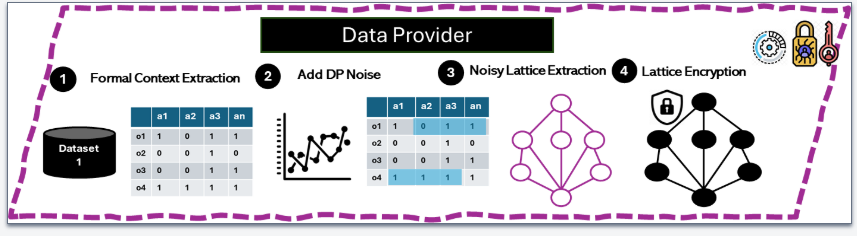

In [15]:
from collections import defaultdict
import json
import networkx as nx
from itertools import chain, combinations
# Now, use the FasterFCA class to process the file
import json
import networkx as nx
from itertools import chain, combinations
import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import random
import sys
import logging
import ast  # To safely evaluate the set structure
import time
import psutil
import math

class LDPHandler:
    def __init__(self, formal_context, context_sensitivity):
        self.formal_context = formal_context  # Original context
        self.context_sensitivity = context_sensitivity  # Sensitivity value for the context
        self.ldp_context = {}  # This will store the noisy (LDP) context

    def randomized_response(self, original_value, epsilon):
        """
        Apply randomized response to a boolean value (True/False).

        :param original_value: The original boolean value (True or False) for an attribute.
        :param epsilon: The privacy budget.
        :return: The noisy value based on randomized response.
        """
        random.seed()  # Ensure random values are different on each run
        p = 1 / (1 + 1 / (epsilon + 1e-10))  # Probability of keeping the original value
        if original_value:
            return random.random() < p  # Return True with probability p
        else:
            return random.random() >= p  # Return False with probability 1 - p

    def apply_aldp_to_formal_context(self):
        """
        Apply Adaptive LDP to the formal context by adding noise to the attribute sets.
        The LDP mechanism is applied to each attribute in the formal context.
        """
        for obj_index, attributes in self.formal_context.items():
            noisy_attributes = set()
            for attribute in attributes:
                # Apply LDP noise to each attribute in the formal context
                epsilon = 1 + 9 * self.context_sensitivity  # Adjust epsilon based on context sensitivity

                # Apply LDP to decide whether to keep the attribute
                noisy_value = self.randomized_response(True, epsilon)  # Simulate adding/removing an attribute

                if noisy_value:
                    noisy_attributes.add(attribute)  # Add to noisy set if 'True'

            self.ldp_context[obj_index] = noisy_attributes

        return self.ldp_context  # Return the noisy context



class StabilityCalculator:
    def __init__(self, formal_context):
        """
        Initialize the stability calculator with a formal context.
        :param formal_context: A dictionary representing the formal context
                               where keys are objects and values are attribute sets.
        """
        self.formal_context = formal_context
        self.objects = set(formal_context.keys())

    def extract_formal_context(self, file_obj):
        """
        Extract the formal context from a file object.
        :param file_obj: File object containing the formal context as lines of attributes.
        :return: The formal context as a dictionary.
        """
        formal_context = {}
        for obj_index, line in enumerate(file_obj, start=1):
            attributes = set(line.strip().split())
            formal_context[obj_index] = attributes
        self.objects = set(formal_context.keys())
        return formal_context
    def support(self, subset):
        """
        Calculate the support for a subset (objset or itemset).

        :param subset: A set of objects (objset) or a set of attributes (itemset).
        :return: The support of the subset.
        """
        if all(obj in self.formal_context for obj in subset):  # Objset (objects)
            common_attributes = set(self.formal_context[next(iter(subset))])  # Start with the attributes of the first object
            for obj in subset:
                common_attributes &= self.formal_context[obj]  # Intersection of attributes across objects
            return len(common_attributes)
        else:  # Itemset (attributes)
            count = 0
            for obj, attributes in self.formal_context.items():
                if subset.issubset(attributes):  # If the object has all attributes in the subset
                    count += 1
            return count



    def build_max_nongen(self, objects, attribute_set_size):
        """
        Build the maximal non-generator set (β).
        :param objects: The set of objects.
        :param attribute_set_size: The size of the attribute set to compare.
        :return: The maximal non-generator set.
        """
        max_nongen = set()
        for obj in sorted(objects, reverse=True):
            if self.support(max_nongen | {obj}) != attribute_set_size:
                max_nongen.add(obj)
        return max_nongen

    def compute_generators(self, obj, alpha, beta, attribute_set_size):
        """
        Compute the number of generators for a specific object.
        :param obj: The current object.
        :param alpha: The α set of objects.
        :param beta: The β set of objects.
        :param attribute_set_size: The size of the attribute set.
        :return: The count of minimal generators.
        """
        min_generators = set()
        non_generators = set()
        for other_obj in (beta | alpha - {obj}):
            if self.support({obj, other_obj}) == attribute_set_size:
                min_generators.add((obj, other_obj))
            else:
                non_generators.add((obj, other_obj))

        generator_count = sum(2 ** (len(min_generators) - i) for i in range(len(min_generators)))
        return generator_count

    def handle_object(self, obj, alpha, beta, attribute_set_size):
        """
        Handle the stability calculation for a single object.
        :param obj: The current object.
        :param alpha: The α set of objects.
        :param beta: The β set of objects.
        :param attribute_set_size: The size of the attribute set.
        :return: The count of generators contributed by this object.
        """
        generator_count = 0
        while alpha:
            generator_count += self.compute_generators(obj, alpha, beta, attribute_set_size)
            alpha, beta = self.update_alpha_beta(beta, attribute_set_size)
        return generator_count

    def update_alpha_beta(self, non_generators, attribute_set_size):
        """
        Update the α and β sets.
        :param non_generators: The current non-generator set.
        :param attribute_set_size: The size of the attribute set.
        :return: Updated α and β sets.
        """
        alpha, beta = set(), set()
        for obj in non_generators:
            if self.support(beta | {obj}) == attribute_set_size:
                alpha.add(obj)
            else:
                beta.add(obj)
        return alpha, beta

    def compute_stability_for_concept(self, extent, intent):
        """
        Compute the stability of a single formal concept.
        :param extent: The set of objects (extent).
        :param intent: The set of attributes (intent).
        :return: The stability value of the concept.
        """
        attribute_set_size = len(intent)
        stability = 0
        generator_set = set()

        for obj in extent:
            if self.support({obj}) == attribute_set_size:
                generator_set.add(obj)

        if generator_set:
            stability = 1 - 1 / (2 ** len(generator_set))

        max_nongen = self.build_max_nongen(extent - generator_set, attribute_set_size)
        alpha, beta = extent - max_nongen, max_nongen

        for obj in alpha:
            stability += self.handle_object(obj, alpha, beta, attribute_set_size)
        # Use int for extremely large calculations

        extent_len = len(extent)

        # Apply a logarithmic scaling to avoid overflow
        if extent_len > 0:
            log_scale = math.log(extent_len + 1)  # Use log of the length for scaling
            stability /= log_scale  # Apply the scaling factor

        stability = min(stability, 1.0)
        return round(stability, 3)


        return round(stability, 3)

    def compute_stability(self, lattice):
        """
        Compute the stability for all concepts in the lattice.
        :param lattice: A list of formal concepts, each as (extent, intent).
        :return: A list of tuples with (extent, intent, stability).
        """
        results = []
        for extent, intent in lattice:
            stability_value = self.compute_stability_for_concept(extent, intent)
            results.append((extent, intent, stability_value))
        return results



    # Function to create the 3D visualization of stability against extent, intent, and stability values
    def plot_stability_3d(self,results):
        # Extracting the data for plotting
        extents = []
        intents = []
        stabilities = []

        for extent, intent, stability in results:
            extents.append(len(extent))  # Use the size of extent as a representation
            intents.append(len(intent))  # Use the size of intent as a representation
            stabilities.append(stability)

        # Convert lists to numpy arrays for plotting
        extents = np.array(extents)
        intents = np.array(intents)
        stabilities = np.array(stabilities)

        # Create a 3D plot
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        # Scatter plot of extent, intent, and stability
        sc = ax.scatter(extents, intents, stabilities, c=stabilities, cmap='viridis', s=50)

        # Adding labels
        ax.set_xlabel('Extent Size')
        ax.set_ylabel('Intent Size')
        ax.set_zlabel('Stability')

        # Add a color bar to indicate stability value
        plt.colorbar(sc)

        # Show the plot
        plt.show()

class FasterFCA:
    def __init__(self, threshold=0.0, context_sensitivity=0.0,privacy=False):
        self.ARCHBIT = (sys.maxsize.bit_length() + 1)  # Dynamically calculate architecture word size
        self.BIT = 1 << (self.ARCHBIT - 1)
        self.formal_context = {}
        self.objects = 0
        self.attributes = 0
        self.context = []
        self.dictBC = {}
        self.lattice = []
        self.threshold = threshold
        self.context_sensitivity = context_sensitivity
        self.context_sensitivity=context_sensitivity
        self.privacy=privacy
        self.StabilityCalculator = StabilityCalculator(self.formal_context)
        self.LDPHandler = LDPHandler(self.formal_context, self.context_sensitivity)
    def extract_formal_context(self, file):
        """
        Extract the formal context from a file with the structure:
        1: {2, 3, 5}
        2: {4, 5, 6}
        """
        self.formal_context = {}

        for line in file:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            try:
                obj_id_str, attributes_str = line.split(":")
                obj_id = int(obj_id_str.strip())
                attributes = ast.literal_eval(attributes_str.strip())

                if not isinstance(attributes, set):
                    raise ValueError("Attributes must be a set.")

                self.formal_context[obj_id] = {int(attr) for attr in attributes}

            except ValueError as ve:
                print(f"Value error in line: '{line}' - {ve}")
            except SyntaxError as se:
                print(f"Syntax error in line: '{line}' - {se}")
            except Exception as e:
                print(f"Unexpected error in line: '{line}' - {e}")

        return self.formal_context

    def read_context(self, formal_context):
        """Process the context from the formal context dictionary using bitwise operations."""
        self.objects = len(formal_context)
        self.attributes = max(attr for attrs in formal_context.values() for attr in attrs)

        context_width = (self.attributes // self.ARCHBIT) + 1
        self.context = [[0] * context_width for _ in range(self.objects)]

        object_to_index = {obj_id: idx for idx, obj_id in enumerate(formal_context.keys())}

        for obj_id, attributes in formal_context.items():
            obj_index = object_to_index[obj_id]
            for attribute in attributes:
                col = (attribute - 1) // self.ARCHBIT
                bit_position = self.ARCHBIT - 1 - ((attribute - 1) % self.ARCHBIT)
                self.context[obj_index][col] |= (1 << bit_position)

    def get_bipartite_cliques(self):
        """Generate bipartite cliques from the formal context using bitset representation."""
        cList = []
        for i in range(self.objects):
            tmpList = []
            tmpObj = [i + 1]
            for j in range(self.attributes):
                if self.context[i][j // self.ARCHBIT] & (1 << (self.ARCHBIT - 1 - (j % self.ARCHBIT))):
                    tmpList.append(j + 1)

            cList.append((tmpObj, tmpList))

        for j in range(self.attributes):
            tmpList = []
            tmpAttr = [j + 1]
            for i in range(self.objects):
                if self.context[i][j // self.ARCHBIT] & (1 << (self.ARCHBIT - 1 - (j % self.ARCHBIT))):
                    tmpList.append(i + 1)

            cList.append((tmpList, tmpAttr))

        return cList

    def condense_list(self, inputlist):
        logging.debug("Initial input list: %s", inputlist)
        clist = []
        to_skip = []

        for x in range(len(inputlist)):
            if x in to_skip:
                continue
            matched = 0
            for y in range(x + 1, len(inputlist)):
                if y in to_skip:
                    continue
                if set(inputlist[x][0]) == set(inputlist[y][0]):
                    tmp_tuple = inputlist[x][0], list(set(inputlist[x][1]).union(set(inputlist[y][1])))
                    logging.debug("Merging on extent: %s and %s", inputlist[x], inputlist[y])
                    clist.append(tmp_tuple)
                    to_skip.append(y)
                    matched = 1
                    break
                elif set(inputlist[x][1]) == set(inputlist[y][1]):
                    tmp_tuple = list(set(inputlist[x][0]).union(set(inputlist[y][0]))), inputlist[x][1]
                    logging.debug("Merging on intent: %s and %s", inputlist[x], inputlist[y])
                    clist.append(tmp_tuple)
                    to_skip.append(y)
                    matched = 1
                    break
            if matched == 0:
                clist.append(inputlist[x])

        logging.debug("Condensed list: %s", clist)
        return clist

    def generate_lattice(self, bCList):
        """Generate the lattice structure."""
        G = nx.DiGraph()  # Using DiGraph to capture hierarchy
        nodes = []

        for concept in bCList:
            extent, intent = concept
            node_name = f"({', '.join(map(str, extent))}), ({', '.join(map(str, intent))})"
            G.add_node(node_name)
            nodes.append((extent, intent, node_name))

        for i, (e1, i1, n1) in enumerate(nodes):
            for j, (e2, i2, n2) in enumerate(nodes):
                if i != j and set(e1).issubset(e2) and set(i2).issubset(i1):
                    G.add_edge(n2, n1)

        pos = nx.spring_layout(G, seed=42)  # Reproducible layout
        nx.draw(G, pos, with_labels=True, node_size=5000, node_color="skyblue")
        nx.write_graphml(G, "lattice.graphml")  # Export to .graphml for external analysis

        return G


    def save_concepts_to_file(self, concepts, output_file):
        """
        Save the computed concepts to a file in JSON format.
        """

        lattice_dict = {}
        for i, (concept, stability) in enumerate(concepts, start=1):
            extent, intent = concept
            intent_str = [str(attr) for attr in intent]
            extent_str = [str(obj) for obj in extent]
            concept_dict = {"Intent": intent_str, "Extent": extent_str, "Stability":stability}

            lattice_dict[f"Concept {i}"] = concept_dict

        with open(output_file, 'w') as f:
            json.dump(lattice_dict, f, indent=4)
    def convert_bcliques_to_lattice(self, bcliques):
        """
        Convert bipartite cliques to lattice format with hashable structures.

        :param bcliques: List of bipartite cliques, each as a tuple (extent, intent).
        :return: Lattice as a list of tuples (frozenset, frozenset).
        """
        lattice = []
        for extent, intent in bcliques:
            # Convert extent and intent to frozensets
            extent_fset = frozenset(extent)
            intent_fset = frozenset(intent)
            lattice.append((extent_fset, intent_fset))
        return lattice



    def stablity_compute(self):
        """
        Compute the stability values for the lattice and filter based on a threshold.

        :param threshold: Minimum stability value required for a concept to be included.
        :return: A tuple containing the filtered lattice with stability values and average stability.
        """
        filtered_lattice_with_stability = []
        total_stability = 0
        count = 0

        for i, concept in enumerate(self.lattice, start=1):
            extent, intent = concept

            stability_value = self.StabilityCalculator.compute_stability_for_concept(extent, intent)
            #print(f"Concept {i}: {concept}, {extent}: {intent},{stability_value}")

            if stability_value >= self.threshold:
                filtered_lattice_with_stability.append(((extent, intent), stability_value))
                #print(f"Concept {i}: {concept}, Stability: {stability_value}")
                total_stability += stability_value
                count += 1

        average_stability = total_stability / count if count > 0 else 0
        return filtered_lattice_with_stability, average_stability

    def run(self, input_file, output_file):
        """
        Execute the Faster FCA algorithm to compute formal concepts and save the result,
        filtering the lattice based on a stability threshold.

        :param input_file: Path to the input file containing the formal context.
        :param output_file: Path to the output file to save results.
        :param threshold: Minimum stability value required for a concept to be included.
        :return: Filtered lattice with stability values in the format [((frozenset, frozenset), stability_value)].
        """
        # Step 1: Read formal context from the input file
        try:
            with open(input_file, 'r') as f:
                self.formal_context = self.extract_formal_context(f)
                #print(self.formal_context)
        except Exception as e:
            raise ValueError(f"Error reading input file: {e}")

        # Step 2: Process the formal context into internal representation
        # Apply LDP to formal context before generating bipartite cliques
        if self.privacy :
           self.LDPHandler.formal_context = self.formal_context
           self.ldp_context=self.LDPHandler.apply_aldp_to_formal_context()
           self.read_context(self.ldp_context)
        else :
          self.read_context(self.formal_context)


        #print(self.compare_formal_contexts())
        # Step 3: Generate bipartite cliques
        bCliques = self.get_bipartite_cliques()

        # Step 4: Condense bipartite cliques iteratively
        bCliquesSize = len(bCliques)
        while True:
            bCliquesCondensed = self.condense_list(bCliques)
            if len(bCliquesCondensed) == bCliquesSize:
                break
            bCliquesSize = len(bCliquesCondensed)
            bCliques = bCliquesCondensed

        # Step 5: Convert bipartite cliques into lattice format
        self.lattice = self.convert_bcliques_to_lattice(bCliques)

        # Debug: Display intermediate results
        #print("Formal Context:", self.formal_context)
        #print("Bipartite Cliques (Lattice):", self.lattice)

        # Step 6: Assign formal context and lattice to StabilityCalculator
        self.StabilityCalculator.formal_context = self.formal_context
        self.StabilityCalculator.lattice = self.lattice

        # Step 7: Compute stability and filter based on threshold
        filtered_lattice_with_stability, average_stability = self.stablity_compute()
        #print(f"Filtered Lattice (Threshold: {self.threshold}):", filtered_lattice_with_stability)
        # print("Average Stability:", average_stability)

        # Step 8: Save the filtered lattice to the output file
        self.save_concepts_to_file(filtered_lattice_with_stability, output_file)

        # Return the filtered lattice in a format compatible with Aggregator
        #print("differences",self.compare_formal_contexts())
        return average_stability,filtered_lattice_with_stability
    def compare_formal_contexts(self):
        """
        Compare the original formal context with the noisy formal context
        and output the differences for each object.

        :param original_context: Original formal context (before LDP).
        :param noisy_context: Noisy formal context (after LDP).
        :return: A dictionary with differences for each object.
        """
        differences = {}

        # Iterate through the objects in the original context
        for obj_index, original_attributes in self.formal_context.items():
            # Get the noisy attributes for the object (default to empty set if not in noisy context)
            noisy_attributes = self.ldp_context.get(obj_index, set())

            # Find attributes that were added or removed
            added_attributes = noisy_attributes - original_attributes
            removed_attributes = original_attributes - noisy_attributes

            # Store the differences
            if added_attributes or removed_attributes:
                differences[obj_index] = {
                    'added': sorted(list(added_attributes)),
                    'removed': sorted(list(removed_attributes))
                }
        #print("Origianal",self.formal_context)
        #print('Noizy',self.ldp_context)
        return differences


# Example Usage
# Run the algorithm
fca = FasterFCA()

fca.run("/content/mushroom/50/IID/provider_1.txt", "/content/mushroom/50/IID/provider_1.txt.json")



(0.24910629921259841,
 [((frozenset({1}),
    frozenset({3,
               7,
               12,
               15,
               16,
               17,
               18,
               19,
               24,
               27,
               29,
               31,
               33,
               39,
               40,
               41,
               42,
               43,
               44,
               50,
               53,
               60,
               61})),
   0.0),
  ((frozenset({2}),
    frozenset({2,
               5,
               7,
               8,
               11,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               24,
               26,
               27,
               28,
               33,
               36,
               37,
               48})),
   0.0),
  ((frozenset({3}),
    frozenset({3,
        

In [16]:
# Example Usage with Stability Check
import time
# Function to get current CPU and RAM usage
def get_system_usage():
    cpu_percent = psutil.cpu_percent(interval=0.1)  # CPU usage as a percentage
    ram_info = psutil.virtual_memory()  # RAM usage information
    ram_percent = ram_info.percent  # RAM usage as a percentage
    ram_used_gb = ram_info.used / (1024 ** 3)  # RAM used in GB
    return cpu_percent, ram_percent, ram_used_gb

num_objects_list = [200, 400, 600,800]
num_attributes_list = [10, 15, 20]
density_list = [0.2, 0.4, 0.6]
num_providers_list = [10]
splitting_types = ["IID", "Non-IID"]
noise_level = 0.0
attribute_correlation = 0.5
skew_factor = 0.5
stability_threshold = 0.5
results = []
for num_objects in num_objects_list:
        for num_attributes in num_attributes_list:
            for density in density_list:
                for splitting_type in splitting_types:
                    dataset_name = f"dataset_{num_objects}_{num_attributes}_{int(density * 10)}_{splitting_type}"
                    data_filename = os.path.join(dataset_name, f"dataset_{num_objects}_{num_attributes}_{int(density * 10)}.data")
                    # Start time
                    TimeBegin = time.time()

                    # Get initial CPU and RAM usage
                    cpu_start, ram_start, ram_used_start = get_system_usage()

                    # Run your FCA algorithm
                    fca = FasterFCA()
                    average_stability, filtered_lattice_with_stability = fca.run(data_filename, data_filename.replace(".data", ".json"))

                    # End time
                    EndBegin = time.time()
                    runtime = EndBegin - TimeBegin

                    # Get final CPU and RAM usage
                    cpu_end, ram_end, ram_used_end = get_system_usage()

                    # Calculate average CPU and RAM usage during the process
                    cpu_avg = (cpu_start + cpu_end) / 2
                    ram_avg = (ram_start + ram_end) / 2
                    ram_used_avg = (ram_used_start + ram_used_end) / 2
                    #print(f"Runtime: {runtime} seconds")
                    #Prepare to store results for the current dataset
                    dataset_results = {
                        'dataset_name': dataset_name,
                        'num_objects': num_objects,
                        'num_attributes': num_attributes,
                        'density': density,
                        'noise_level': noise_level,
                        'type_partition': splitting_type,
                        'average_stability': average_stability,
                        'Runtime': runtime,
                        'CPU_Usage': cpu_avg,
                        'RAM_Usage': ram_avg,
                        'RAM_Used': ram_used_avg,
                        #,'filtered_lattice_with_stability': filtered_lattice_with_stability

                    }
                    results.append(dataset_results)

results

Value error in line: '1: {np.int64(9), np.int64(3)}' - malformed node or string on line 1: <ast.Call object at 0x7f2802662590>
Value error in line: '2: {np.int64(1), np.int64(2), np.int64(4), np.int64(5)}' - malformed node or string on line 1: <ast.Call object at 0x7f27e4de6c90>
Value error in line: '3: {np.int64(8), np.int64(4)}' - malformed node or string on line 1: <ast.Call object at 0x7f27e4de44d0>
Value error in line: '4: {np.int64(8), np.int64(10)}' - malformed node or string on line 1: <ast.Call object at 0x7f27e4de6610>
Value error in line: '5: {np.int64(8), np.int64(3)}' - malformed node or string on line 1: <ast.Call object at 0x7f2802662590>
Value error in line: '6: {np.int64(8), np.int64(6)}' - malformed node or string on line 1: <ast.Call object at 0x7f27e4de6e10>
Value error in line: '7: {np.int64(8), np.int64(9)}' - malformed node or string on line 1: <ast.Call object at 0x7f27e65aca10>
Value error in line: '8: {np.int64(5), np.int64(7)}' - malformed node or string on l

ValueError: max() iterable argument is empty

In [ ]:
pd.DataFrame(results).to_csv('results.csv', index=False)

## Interactive Stability Analysis Dashboard
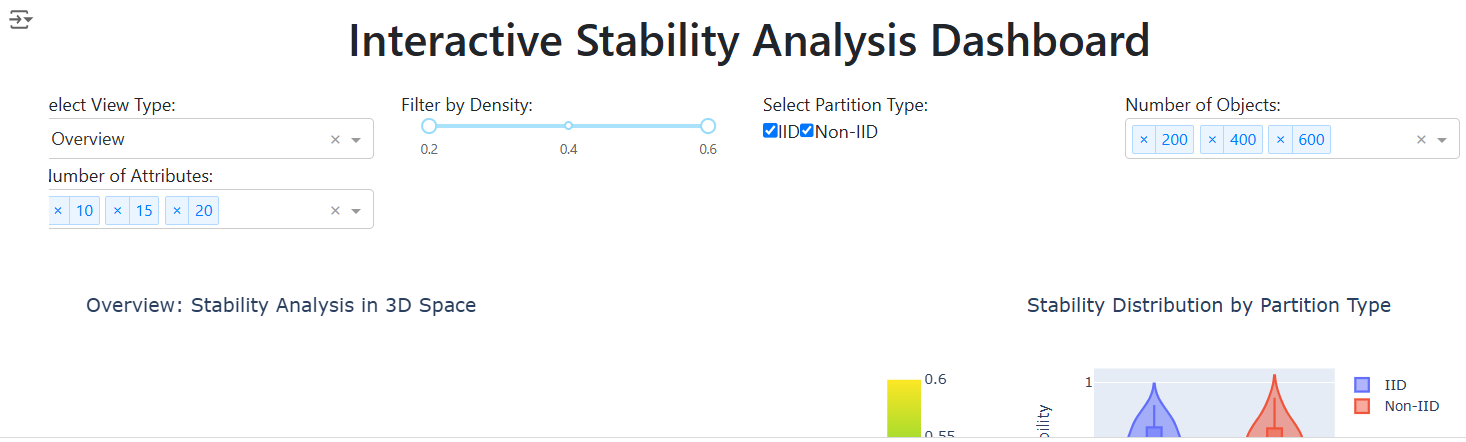

In [7]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
from dash import Dash, dcc, html, Input, Output, State
import dash_bootstrap_components as dbc

def create_advanced_dashboard(df):
    app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

    # Calculate additional metrics
    df['efficiency'] = df['average_stability'] / df['Runtime']

    app.layout = html.Div([
        dbc.NavbarSimple(
            brand="Advanced Stability Analysis Dashboard",
            brand_href="#",
            color="primary",
            dark=True,
        ),

        dbc.Container([
            dbc.Row([
                # Left Sidebar - Controls
                dbc.Col([
                    dbc.Card([
                        dbc.CardHeader("Analysis Controls"),
                        dbc.CardBody([
                            html.Label("View Type"),
                            dcc.Dropdown(
                                id='view-type',
                                options=[
                                    {'label': 'Stability Analysis', 'value': 'stability'},
                                    {'label': 'Resource Usage', 'value': 'resource'},
                                    {'label': 'Performance Matrix', 'value': 'performance'},
                                    {'label': 'Comparative Analysis', 'value': 'comparative'}
                                ],
                                value='stability',
                                clearable=False
                            ),
                            html.Hr(),
                            html.Label("Dataset Configuration"),
                            dcc.Dropdown(
                                id='partition-types',
                                options=[{'label': i, 'value': i} for i in df['type_partition'].unique()],
                                value=df['type_partition'].unique().tolist(),
                                multi=True
                            ),
                            html.Br(),
                            html.Label("Objects Range"),
                            dcc.RangeSlider(
                                id='objects-range',
                                min=df['num_objects'].min(),
                                max=df['num_objects'].max(),
                                value=[df['num_objects'].min(), df['num_objects'].max()],
                                marks={int(i): str(i) for i in df['num_objects'].unique()},
                                step=None
                            ),
                            html.Br(),
                            html.Label("Attributes"),
                            dcc.Dropdown(
                                id='attributes',
                                options=[{'label': f'{i} attributes', 'value': i}
                                        for i in sorted(df['num_attributes'].unique())],
                                value=df['num_attributes'].unique().tolist(),
                                multi=True
                            ),
                            html.Br(),
                            html.Label("Density Range"),
                            dcc.RangeSlider(
                                id='density-range',
                                min=df['density'].min(),
                                max=df['density'].max(),
                                value=[df['density'].min(), df['density'].max()],
                                marks={i/10: f'{i/10:.1f}' for i in range(2, 7, 1)},
                                step=0.1
                            )
                        ])
                    ], className="mb-3"),

                    dbc.Card([
                        dbc.CardHeader("Quick Stats"),
                        dbc.CardBody(id='quick-stats')
                    ])
                ], width=3),

                # Main Content Area
                dbc.Col([
                    dbc.Row([
                        dbc.Col([
                            dbc.Card([
                                dbc.CardHeader(id='main-chart-title'),
                                dbc.CardBody([
                                    dcc.Graph(id='main-chart')
                                ])
                            ])
                        ], width=12)
                    ], className="mb-3"),

                    dbc.Row([
                        dbc.Col([
                            dbc.Card([
                                dbc.CardHeader("Supporting Analysis"),
                                dbc.CardBody([
                                    dcc.Graph(id='support-chart-1')
                                ])
                            ])
                        ], width=6),
                        dbc.Col([
                            dbc.Card([
                                dbc.CardHeader("Resource Metrics"),
                                dbc.CardBody([
                                    dcc.Graph(id='support-chart-2')
                                ])
                            ])
                        ], width=6)
                    ])
                ], width=9)
            ])
        ], fluid=True)
    ])

    @app.callback(
        [Output('main-chart', 'figure'),
         Output('support-chart-1', 'figure'),
         Output('support-chart-2', 'figure'),
         Output('main-chart-title', 'children'),
         Output('quick-stats', 'children')],
        [Input('view-type', 'value'),
         Input('partition-types', 'value'),
         Input('objects-range', 'value'),
         Input('attributes', 'value'),
         Input('density-range', 'value')]
    )
    def update_charts(view_type, partition_types, objects_range, attributes, density_range):
        filtered_df = df[
            (df['type_partition'].isin(partition_types)) &
            (df['num_objects'].between(objects_range[0], objects_range[1])) &
            (df['num_attributes'].isin(attributes)) &
            (df['density'].between(density_range[0], density_range[1]))
        ]

        if view_type == 'stability':
            main_fig = px.scatter_3d(
                filtered_df,
                x='num_objects',
                y='num_attributes',
                z='average_stability',
                color='type_partition',
                size='efficiency',
                hover_data=['density', 'Runtime'],
                title='Stability Analysis Matrix'
            )

            support_1 = px.box(
                filtered_df,
                x='type_partition',
                y='average_stability',
                color='type_partition',
                points='all',
                title='Stability Distribution'
            )

            support_2 = px.scatter(
                filtered_df,
                x='density',
                y='average_stability',
                color='type_partition',
                size='num_objects',
                trendline='ols',
                title='Stability vs Density'
            )

            title = "3D Stability Analysis"

        elif view_type == 'resource':
            main_fig = px.scatter(
                filtered_df,
                x='CPU_Usage',
                y='RAM_Used',
                color='type_partition',
                size='Runtime',
                hover_data=['num_objects', 'num_attributes'],
                title='Resource Usage Analysis'
            )

            support_1 = px.line(
                filtered_df.groupby('num_objects')['Runtime'].mean().reset_index(),
                x='num_objects',
                y='Runtime',
                title='Average Runtime by Dataset Size'
            )

            support_2 = px.bar(
                filtered_df.groupby('type_partition')[['CPU_Usage', 'RAM_Usage']].mean().reset_index(),
                x='type_partition',
                y=['CPU_Usage', 'RAM_Usage'],
                title='Average Resource Usage by Partition Type',
                barmode='group'
            )

            title = "Resource Usage Analysis"

        elif view_type == 'performance':
            main_fig = px.density_heatmap(
                filtered_df,
                x='num_attributes',
                y='num_objects',
                z='efficiency',
                color_continuous_scale='RdYlBu',
                title='Performance Matrix'
            )

            support_1 = px.scatter(
                filtered_df,
                x='Runtime',
                y='average_stability',
                color='type_partition',
                size='num_objects',
                trendline='ols',
                title='Stability vs Runtime'
            )

            support_2 = px.line(
                filtered_df.groupby(['type_partition', 'density'])['efficiency'].mean().reset_index(),
                x='density',
                y='efficiency',
                color='type_partition',
                title='Efficiency vs Density'
            )

            title = "Performance Matrix Analysis"

        else:  # comparative
            main_fig = go.Figure()
            for partition in partition_types:
                subset = filtered_df[filtered_df['type_partition'] == partition]
                main_fig.add_trace(go.Scatter(
                    x=subset['num_objects'],
                    y=subset['average_stability'],
                    mode='lines+markers',
                    name=partition
                ))
            main_fig.update_layout(
                title='Comparative Stability Analysis',
                xaxis_title='Number of Objects',
                yaxis_title='Average Stability'
            )

            support_1 = px.violin(
                filtered_df,
                x='type_partition',
                y='Runtime',
                color='type_partition',
                box=True,
                points='all',
                title='Runtime Distribution'
            )

            support_2 = px.scatter_matrix(
                filtered_df,
                dimensions=['average_stability', 'Runtime', 'CPU_Usage', 'RAM_Used'],
                color='type_partition',
                title='Metrics Correlation Matrix'
            )

            title = "Comparative Analysis"

        # Quick Stats
        stats = html.Div([
            html.P(f"Average Stability: {filtered_df['average_stability'].mean():.3f}"),
            html.P(f"Average Runtime: {filtered_df['Runtime'].mean():.2f}s"),
            html.P(f"Average CPU Usage: {filtered_df['CPU_Usage'].mean():.1f}%"),
            html.P(f"Average RAM Used: {filtered_df['RAM_Used'].mean():.2f}GB")
        ])

        return main_fig, support_1, support_2, title, stats

    return app

# Load data and run
df = pd.read_csv("results.csv")
app = create_advanced_dashboard(df)
app.run_server(debug=True)

FileNotFoundError: [Errno 2] No such file or directory: 'results.csv'

### Server-Side Computation and Communication

The cloud aggregator plays a central role in securely aggregating encrypted concept lattices from participants in the Federated Formal Concept Analysis (FedFCA) framework. Upon receiving an encrypted local lattice L_{P_i}^{Enc} from a participant, the server decrypts it to retrieve the original lattice L_{P_i}.

If the global lattice L_{Global} is empty, the server initializes it with L_{P_i}. Otherwise, the server enters an aggregation phase, where it computes the supremum (sup = (A_i ∪ A_j, (B_i ∩ B_j)')) and infimum (inf = ((A_i ∩ A_j)', B_i ∪ B_j)) for each concept (A_i, B_i) in L_{P_i} and each concept (A_j, B_j) in L_{Global}. These new concepts are added to L_{Global}, iteratively enriching it with insights from all participants. This process ensures the creation of a unified and comprehensive global lattice for further analysis.

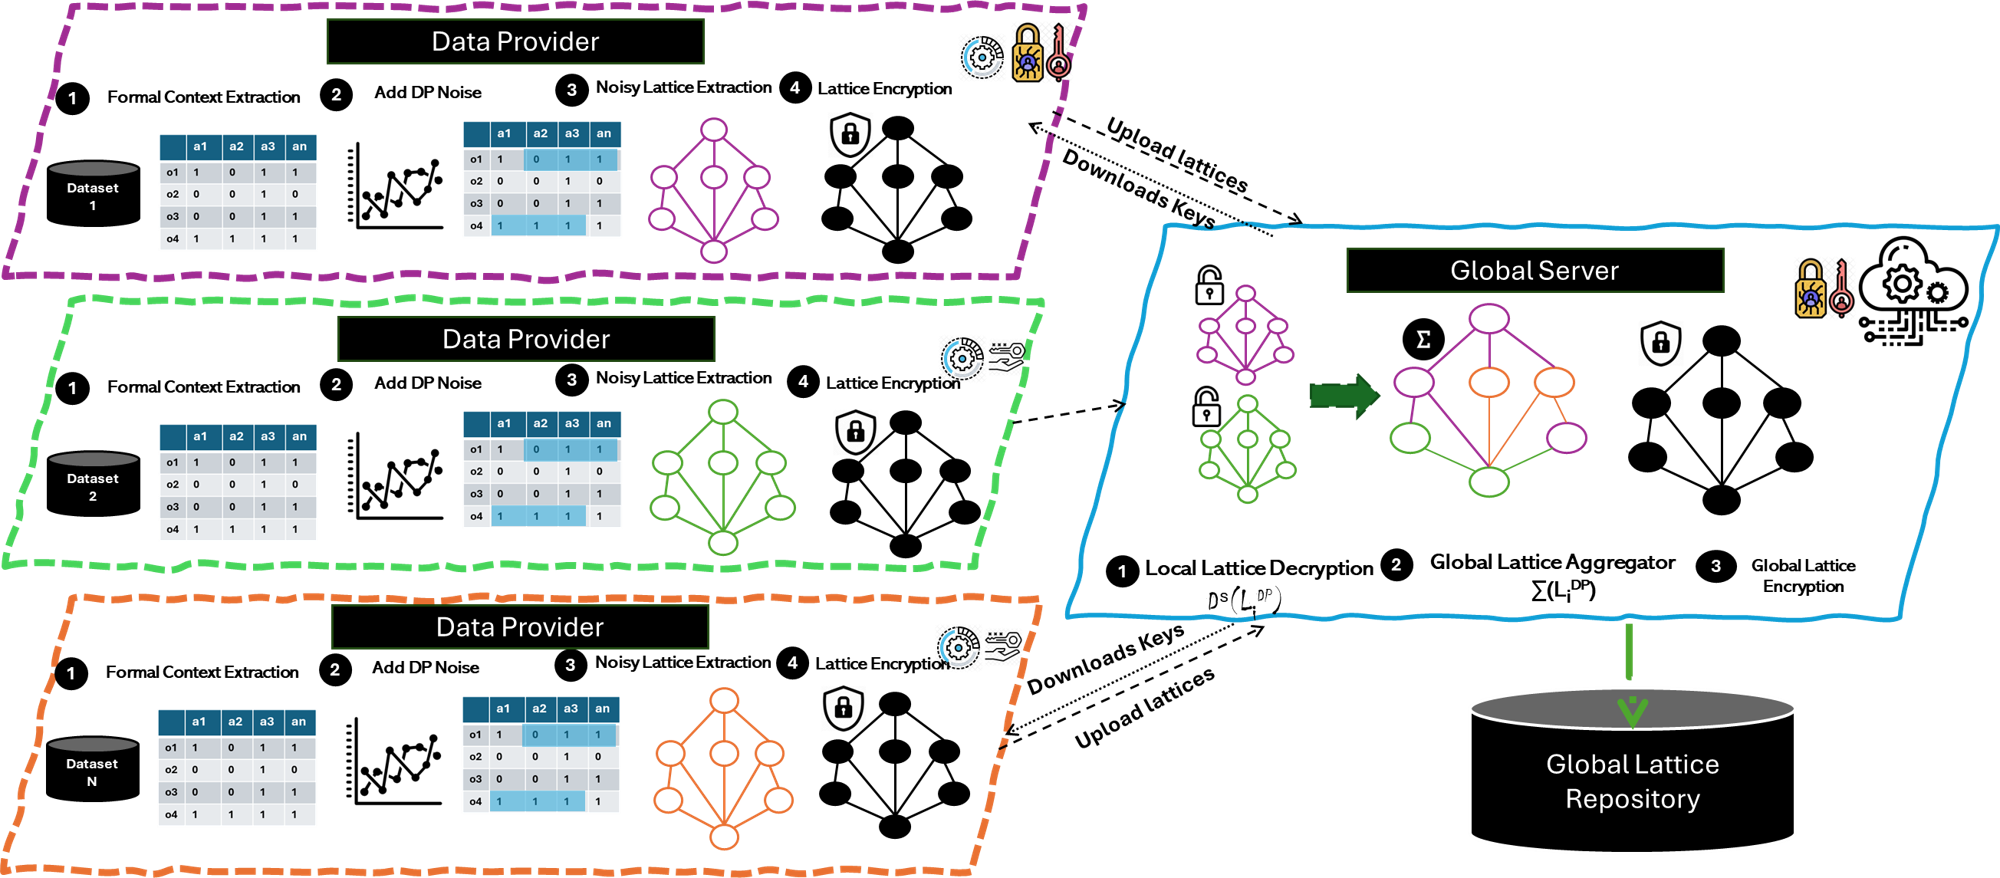

In [21]:
import logging
import concurrent.futures
from itertools import combinations, chain
import networkx as nx
import matplotlib.pyplot as plt
import uuid
import logging
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.mixture import GaussianMixture
from collections import defaultdict
import json
import networkx as nx
from itertools import chain, combinations
# Now, use the FasterFCA class to process the file
import json
import networkx as nx
from itertools import chain, combinations
import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import random
import sys
import logging
import math

import ast  # To safely evaluate the set structure
from cryptography.fernet import Fernet
import tenseal as ts
class LDPHandler:
    def __init__(self, formal_context):
        self.formal_context = formal_context
        self.ldp_context = {}
        self.runtime = None

    # ---------------------------
    # COMPUTE DENSITY ρ_i
    # ---------------------------
    def compute_density(self):
        G = len(self.formal_context)
        if G == 0:
            return 0

        M = len(
            set().union(*self.formal_context.values())
        )

        total_possible = G * M
        total_ones = sum(len(attrs) for attrs in self.formal_context.values())

        return total_ones / total_possible if total_possible > 0 else 0

    # ---------------------------
    # COMPUTE κ_i
    # ---------------------------
    def compute_kappa(self):
        G = len(self.formal_context)
        if G == 0:
            return 0

        all_attrs = set().union(*self.formal_context.values())

        kappa_values = []

        for m in all_attrs:
            support = sum(1 for attrs in self.formal_context.values() if m in attrs)
            p = support / G
            kappa_m = 4 * p * (1 - p)
            kappa_values.append(kappa_m)

        return sum(kappa_values) / len(kappa_values) if kappa_values else 0

    # ---------------------------
    # COMPUTE ADAPTIVE EPSILON
    # ---------------------------
    def compute_adaptive_epsilon(self):
        rho = self.compute_density()
        kappa = self.compute_kappa()

        epsilon = 1 - (rho + kappa) / 2

        return max(0, min(1, epsilon))

    # ---------------------------
    # RANDOMIZED RESPONSE
    # ---------------------------
    def randomized_response(self, value, epsilon):
        p = np.exp(epsilon / 2) / (np.exp(epsilon / 2) + 1)

        if value == 1:
            return 1 if random.random() < p else 0
        else:
            return 1 if random.random() > p else 0

    # ---------------------------
    # APPLY ADAPTIVE LDP
    # ---------------------------
    def apply_aldp_to_formal_context(self):

        start = time.time()

        epsilon = self.compute_adaptive_epsilon()

        for obj, attrs in self.formal_context.items():
            noisy_attrs = set()

            for attr in attrs:
                if self.randomized_response(1, epsilon) == 1:
                    noisy_attrs.add(attr)

            self.ldp_context[obj] = noisy_attrs

        self.runtime = time.time() - start

        return self.ldp_context


class StabilityCalculator:
    def __init__(self, formal_context):
        """
        Initialize the stability calculator with a formal context.
        :param formal_context: A dictionary representing the formal context
                               where keys are objects and values are attribute sets.
        """
        self.formal_context = formal_context
        self.objects = set(formal_context.keys())

    def extract_formal_context(self, file_obj):
        """
        Extract the formal context from a file object.
        :param file_obj: File object containing the formal context as lines of attributes.
        :return: The formal context as a dictionary.
        """
        formal_context = {}
        for obj_index, line in enumerate(file_obj, start=1):
            attributes = set(line.strip().split())
            formal_context[obj_index] = attributes
        self.objects = set(formal_context.keys())
        return formal_context
    def support(self, subset):
        """
        Calculate the support for a subset (objset or itemset).

        :param subset: A set of objects (objset) or a set of attributes (itemset).
        :return: The support of the subset.
        """
        if all(obj in self.formal_context for obj in subset):  # Objset (objects)
            common_attributes = set(self.formal_context[next(iter(subset))])  # Start with the attributes of the first object
            for obj in subset:
                common_attributes &= self.formal_context[obj]  # Intersection of attributes across objects
            return len(common_attributes)
        else:  # Itemset (attributes)
            count = 0
            for obj, attributes in self.formal_context.items():
                if subset.issubset(attributes):  # If the object has all attributes in the subset
                    count += 1
            return count



    def build_max_nongen(self, objects, attribute_set_size):
        """
        Build the maximal non-generator set (β).
        :param objects: The set of objects.
        :param attribute_set_size: The size of the attribute set to compare.
        :return: The maximal non-generator set.
        """
        max_nongen = set()
        for obj in sorted(objects, reverse=True):
            if self.support(max_nongen | {obj}) != attribute_set_size:
                max_nongen.add(obj)
        return max_nongen

    def compute_generators(self, obj, alpha, beta, attribute_set_size):
        """
        Compute the number of generators for a specific object.
        :param obj: The current object.
        :param alpha: The α set of objects.
        :param beta: The β set of objects.
        :param attribute_set_size: The size of the attribute set.
        :return: The count of minimal generators.
        """
        min_generators = set()
        non_generators = set()
        for other_obj in (beta | alpha - {obj}):
            if self.support({obj, other_obj}) == attribute_set_size:
                min_generators.add((obj, other_obj))
            else:
                non_generators.add((obj, other_obj))

        generator_count = sum(2 ** (len(min_generators) - i) for i in range(len(min_generators)))
        return generator_count

    def handle_object(self, obj, alpha, beta, attribute_set_size):
        """
        Handle the stability calculation for a single object.
        :param obj: The current object.
        :param alpha: The α set of objects.
        :param beta: The β set of objects.
        :param attribute_set_size: The size of the attribute set.
        :return: The count of generators contributed by this object.
        """
        generator_count = 0
        while alpha:
            generator_count += self.compute_generators(obj, alpha, beta, attribute_set_size)
            alpha, beta = self.update_alpha_beta(beta, attribute_set_size)
        return generator_count

    def update_alpha_beta(self, non_generators, attribute_set_size):
        """
        Update the α and β sets.
        :param non_generators: The current non-generator set.
        :param attribute_set_size: The size of the attribute set.
        :return: Updated α and β sets.
        """
        alpha, beta = set(), set()
        for obj in non_generators:
            if self.support(beta | {obj}) == attribute_set_size:
                alpha.add(obj)
            else:
                beta.add(obj)
        return alpha, beta

    def compute_stability_for_concept_old(self, extent, intent):
        """
        Compute the stability of a single formal concept.
        :param extent: The set of objects (extent).
        :param intent: The set of attributes (intent).
        :return: The stability value of the concept.
        """
        attribute_set_size = len(intent)
        stability = 0
        generator_set = set()

        for obj in extent:
            if self.support({obj}) == attribute_set_size:
                generator_set.add(obj)

        if generator_set:
            stability = 1 - 1 / (2 ** len(generator_set))

        max_nongen = self.build_max_nongen(extent - generator_set, attribute_set_size)
        alpha, beta = extent - max_nongen, max_nongen

        for obj in alpha:
            stability += self.handle_object(obj, alpha, beta, attribute_set_size)

        stability /= (2 ** len(extent))
        stability = min(stability, 1.0)
        return round(stability, 3)
    def compute_stability_for_concept(self, extent, intent):
        """
        Compute the stability of a single formal concept.
        :param extent: The set of objects (extent).
        :param intent: The set of attributes (intent).
        :return: The stability value of the concept.
        """
        attribute_set_size = len(intent)
        stability = 0
        generator_set = set()

        for obj in extent:
            if self.support({obj}) == attribute_set_size:
                generator_set.add(obj)

        if generator_set:
            stability = 1 - 1 / (2 ** len(generator_set))

        max_nongen = self.build_max_nongen(extent - generator_set, attribute_set_size)
        alpha, beta = extent - max_nongen, max_nongen

        for obj in alpha:
            stability += self.handle_object(obj, alpha, beta, attribute_set_size)
        # Use int for extremely large calculations

        extent_len = len(extent)

        # Apply a logarithmic scaling to avoid overflow
        if extent_len > 0:
            log_scale = math.log(extent_len + 1)  # Use log of the length for scaling
            stability /= log_scale  # Apply the scaling factor

        stability = min(stability, 1.0)
        return round(stability, 3)
    def compute_stability(self, lattice):
        """
        Compute the stability for all concepts in the lattice.
        :param lattice: A list of formal concepts, each as (extent, intent).
        :return: A list of tuples with (extent, intent, stability).
        """
        results = []
        for extent, intent in lattice:
            stability_value = self.compute_stability_for_concept(extent, intent)
            results.append((extent, intent, stability_value))
        return results



    # Function to create the 3D visualization of stability against extent, intent, and stability values
    def plot_stability_3d(self,results):
        # Extracting the data for plotting
        extents = []
        intents = []
        stabilities = []

        for extent, intent, stability in results:
            extents.append(len(extent))  # Use the size of extent as a representation
            intents.append(len(intent))  # Use the size of intent as a representation
            stabilities.append(stability)

        # Convert lists to numpy arrays for plotting
        extents = np.array(extents)
        intents = np.array(intents)
        stabilities = np.array(stabilities)

        # Create a 3D plot
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        # Scatter plot of extent, intent, and stability
        sc = ax.scatter(extents, intents, stabilities, c=stabilities, cmap='viridis', s=50)

        # Adding labels
        ax.set_xlabel('Extent Size')
        ax.set_ylabel('Intent Size')
        ax.set_zlabel('Stability')

        # Add a color bar to indicate stability value
        plt.colorbar(sc)

        # Show the plot
        plt.show()

class FasterFCA:
    def __init__(self, threshold=0.0, context_sensitivity=0.0):
        self.ARCHBIT = (sys.maxsize.bit_length() + 1)  # Dynamically calculate architecture word size
        self.BIT = 1 << (self.ARCHBIT - 1)
        self.formal_context = {}
        self.objects = 0
        self.attributes = 0
        self.context = []
        self.dictBC = {}
        self.lattice = []
        self.threshold = threshold
        self.context_sensitivity = context_sensitivity
        self.context_sensitivity=context_sensitivity
        self.StabilityCalculator = StabilityCalculator(self.formal_context)
        self.LDPHandler = LDPHandler(self.formal_context)
    def extract_formal_context(self, file):
        """
        Extract the formal context from a file.
        Accepts both:
            1: {2, 3, 5}
            2: [4, 5, 6]
        Automatically converts lists to sets.
        """

        self.formal_context = {}

        for line in file:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            try:
                obj_id_str, attributes_str = line.split(":")
                obj_id = int(obj_id_str.strip())

                # Safely evaluate structure
                attributes = ast.literal_eval(attributes_str.strip())

                # 🔥 FIX: Convert list → set automatically
                if isinstance(attributes, list):
                    attributes = set(attributes)

                # 🔥 FIX: Ensure tuple also converted
                if isinstance(attributes, tuple):
                    attributes = set(attributes)

                if not isinstance(attributes, set):
                    raise ValueError("Attributes must be convertible to a set.")

                # Ensure all attributes are int
                self.formal_context[obj_id] = {int(attr) for attr in attributes}

            except Exception as e:
                print(f"Parsing error in line: '{line}' → {e}")

        return self.formal_context

    def read_context(self, formal_context):
        """Process the context from the formal context dictionary using bitwise operations."""
        self.objects = len(formal_context)
        self.attributes = max(attr for attrs in formal_context.values() for attr in attrs)

        context_width = (self.attributes // self.ARCHBIT) + 1
        self.context = [[0] * context_width for _ in range(self.objects)]

        object_to_index = {obj_id: idx for idx, obj_id in enumerate(formal_context.keys())}

        for obj_id, attributes in formal_context.items():
            obj_index = object_to_index[obj_id]
            for attribute in attributes:
                col = (attribute - 1) // self.ARCHBIT
                bit_position = self.ARCHBIT - 1 - ((attribute - 1) % self.ARCHBIT)
                self.context[obj_index][col] |= (1 << bit_position)

    def get_bipartite_cliques(self):
        """Generate bipartite cliques from the formal context using bitset representation."""
        cList = []
        for i in range(self.objects):
            tmpList = []
            tmpObj = [i + 1]
            for j in range(self.attributes):
                if self.context[i][j // self.ARCHBIT] & (1 << (self.ARCHBIT - 1 - (j % self.ARCHBIT))):
                    tmpList.append(j + 1)

            cList.append((tmpObj, tmpList))

        for j in range(self.attributes):
            tmpList = []
            tmpAttr = [j + 1]
            for i in range(self.objects):
                if self.context[i][j // self.ARCHBIT] & (1 << (self.ARCHBIT - 1 - (j % self.ARCHBIT))):
                    tmpList.append(i + 1)

            cList.append((tmpList, tmpAttr))

        return cList

    def condense_list(self, inputlist):
        logging.debug("Initial input list: %s", inputlist)
        clist = []
        to_skip = []

        for x in range(len(inputlist)):
            if x in to_skip:
                continue
            matched = 0
            for y in range(x + 1, len(inputlist)):
                if y in to_skip:
                    continue
                if set(inputlist[x][0]) == set(inputlist[y][0]):
                    tmp_tuple = inputlist[x][0], list(set(inputlist[x][1]).union(set(inputlist[y][1])))
                    logging.debug("Merging on extent: %s and %s", inputlist[x], inputlist[y])
                    clist.append(tmp_tuple)
                    to_skip.append(y)
                    matched = 1
                    break
                elif set(inputlist[x][1]) == set(inputlist[y][1]):
                    tmp_tuple = list(set(inputlist[x][0]).union(set(inputlist[y][0]))), inputlist[x][1]
                    logging.debug("Merging on intent: %s and %s", inputlist[x], inputlist[y])
                    clist.append(tmp_tuple)
                    to_skip.append(y)
                    matched = 1
                    break
            if matched == 0:
                clist.append(inputlist[x])

        logging.debug("Condensed list: %s", clist)
        return clist

    def generate_lattice(self, bCList):
        """Generate the lattice structure."""
        G = nx.DiGraph()  # Using DiGraph to capture hierarchy
        nodes = []

        for concept in bCList:
            extent, intent = concept
            node_name = f"({', '.join(map(str, extent))}), ({', '.join(map(str, intent))})"
            G.add_node(node_name)
            nodes.append((extent, intent, node_name))

        for i, (e1, i1, n1) in enumerate(nodes):
            for j, (e2, i2, n2) in enumerate(nodes):
                if i != j and set(e1).issubset(e2) and set(i2).issubset(i1):
                    G.add_edge(n2, n1)

        pos = nx.spring_layout(G, seed=42)  # Reproducible layout
        nx.draw(G, pos, with_labels=True, node_size=5000, node_color="skyblue")
        nx.write_graphml(G, "lattice.graphml")  # Export to .graphml for external analysis

        return G


    def save_concepts_to_file(self, concepts, output_file):
        """
        Save the computed concepts to a file in JSON format.
        """

        lattice_dict = {}
        for i, (concept, stability) in enumerate(concepts, start=1):
            extent, intent = concept
            intent_str = [str(attr) for attr in intent]
            extent_str = [str(obj) for obj in extent]
            concept_dict = {"Intent": intent_str, "Extent": extent_str, "Stability":stability}

            lattice_dict[f"Concept {i}"] = concept_dict

        with open(output_file, 'w') as f:
            json.dump(lattice_dict, f, indent=4)
    def convert_bcliques_to_lattice(self, bcliques):
        """
        Convert bipartite cliques to lattice format with hashable structures.

        :param bcliques: List of bipartite cliques, each as a tuple (extent, intent).
        :return: Lattice as a list of tuples (frozenset, frozenset).
        """
        lattice = []
        for extent, intent in bcliques:
            # Convert extent and intent to frozensets
            extent_fset = frozenset(extent)
            intent_fset = frozenset(intent)
            lattice.append((extent_fset, intent_fset))
        return lattice



    def stablity_compute(self):
        """
        Compute the stability values for the lattice and filter based on a threshold.

        :param threshold: Minimum stability value required for a concept to be included.
        :return: A tuple containing the filtered lattice with stability values and average stability.
        """
        filtered_lattice_with_stability = []
        total_stability = 0
        count = 0

        for i, concept in enumerate(self.lattice, start=1):
            extent, intent = concept

            stability_value = self.StabilityCalculator.compute_stability_for_concept(extent, intent)
            #print(f"Concept {i}: {concept}, {extent}: {intent},{stability_value}")

            if stability_value >= self.threshold:
                filtered_lattice_with_stability.append(((extent, intent), stability_value))
                #print(f"Concept {i}: {concept}, Stability: {stability_value}")
                total_stability += stability_value
                count += 1

        average_stability = total_stability / count if count > 0 else 0
        return filtered_lattice_with_stability, average_stability

    def run(self, input_file, output_file):
        """
        Execute the Faster FCA algorithm to compute formal concepts and save the result,
        filtering the lattice based on a stability threshold.

        :param input_file: Path to the input file containing the formal context.
        :param output_file: Path to the output file to save results.
        :param threshold: Minimum stability value required for a concept to be included.
        :return: Filtered lattice with stability values in the format [((frozenset, frozenset), stability_value)].
        """
        # Step 1: Read formal context from the input file
        try:
            with open(input_file, 'r') as f:
                self.formal_context = self.extract_formal_context(f)
                #print(self.formal_context)
        except Exception as e:
            raise ValueError(f"Error reading input file: {e}")

        # Step 2: Process the formal context into internal representation
        self.LDPHandler.formal_context = self.formal_context
        self.ldp_context=self.LDPHandler.apply_aldp_to_formal_context()
        self.read_context(self.ldp_context)
         # Apply LDP to formal context before generating bipartite cliques
        #print(self.compare_formal_contexts())
        # Step 3: Generate bipartite cliques
        bCliques = self.get_bipartite_cliques()

        # Step 4: Condense bipartite cliques iteratively
        bCliquesSize = len(bCliques)
        while True:
            bCliquesCondensed = self.condense_list(bCliques)
            if len(bCliquesCondensed) == bCliquesSize:
                break
            bCliquesSize = len(bCliquesCondensed)
            bCliques = bCliquesCondensed

        # Step 5: Convert bipartite cliques into lattice format
        self.lattice = self.convert_bcliques_to_lattice(bCliques)

        # Debug: Display intermediate results
        #print("Formal Context:", self.formal_context)
        #print("Bipartite Cliques (Lattice):", self.lattice)

        # Step 6: Assign formal context and lattice to StabilityCalculator
        self.StabilityCalculator.formal_context = self.formal_context
        self.StabilityCalculator.lattice = self.lattice

        # Step 7: Compute stability and filter based on threshold
        filtered_lattice_with_stability, average_stability = self.stablity_compute()
        #print(f"Filtered Lattice (Threshold: {self.threshold}):", filtered_lattice_with_stability)
        # print("Average Stability:", average_stability)

        # Step 8: Save the filtered lattice to the output file
        self.save_concepts_to_file(filtered_lattice_with_stability, output_file)

        # Return the filtered lattice in a format compatible with Aggregator
        #print("differences",self.compare_formal_contexts())
        return filtered_lattice_with_stability
    def compare_formal_contexts(self):
        """
        Compare the original formal context with the noisy formal context
        and output the differences for each object.

        :param original_context: Original formal context (before LDP).
        :param noisy_context: Noisy formal context (after LDP).
        :return: A dictionary with differences for each object.
        """
        differences = {}

        # Iterate through the objects in the original context
        for obj_index, original_attributes in self.formal_context.items():
            # Get the noisy attributes for the object (default to empty set if not in noisy context)
            noisy_attributes = self.ldp_context.get(obj_index, set())

            # Find attributes that were added or removed
            added_attributes = noisy_attributes - original_attributes
            removed_attributes = original_attributes - noisy_attributes

            # Store the differences
            if added_attributes or removed_attributes:
                differences[obj_index] = {
                    'added': sorted(list(added_attributes)),
                    'removed': sorted(list(removed_attributes))
                }
        #print("Origianal",self.formal_context)
        #print('Noizy',self.ldp_context)
        return differences




class Encryption:
    def __init__(self):
        # Generate a key for symmetric encryption
        self.symmetric_key = Fernet.generate_key()
        self.cipher_suite = Fernet(self.symmetric_key)
        self.runtime=None
        # Create a TenSEAL context for homomorphic encryption
        self.context = ts.context(ts.SCHEME_TYPE.BFV, poly_modulus_degree=4096, plain_modulus=1032193)

    def symmetric_encrypt(self, message):
        """Encrypt a message using symmetric encryption (Fernet)."""
        TimeBegin=time.time()
        if isinstance(message, str):
            message = message.encode()
        EndTime=time.time()
        self.runtime=EndTime-TimeBegin
        return self.cipher_suite.encrypt(message)

    def symmetric_decrypt(self, encrypted_message):
        """Decrypt a message using symmetric encryption (Fernet)."""
        TimeBegin=time.time()
        decrypted_message = self.cipher_suite.decrypt(encrypted_message)
        EndTime=time.time()
        self.runtime=EndTime-TimeBegin
        return decrypted_message.decode()

    def homomorphic_encrypt(self, message):
        """Encrypt a list of integers using homomorphic encryption (TenSEAL)."""
        if not isinstance(message, list):
            raise ValueError("Homomorphic encryption requires a list of integers.")
        return ts.bfv_vector(self.context, message)

    def homomorphic_decrypt(self, encrypted_vector):
        """Decrypt a homomorphically encrypted vector (TenSEAL)."""
        return encrypted_vector.decrypt()

    def save_symmetric_key(self, file_path):
        """Save the symmetric key to a file."""
        with open(file_path, "wb") as key_file:
            key_file.write(self.symmetric_key)

    def load_symmetric_key(self, file_path):
        """Load the symmetric key from a file."""
        with open(file_path, "rb") as key_file:
            self.symmetric_key = key_file.read()
        self.cipher_suite = Fernet(self.symmetric_key)

    def save_context(self, file_path):
        """Save the TenSEAL context to a file."""
        with open(file_path, "wb") as context_file:
            context_file.write(self.context.serialize())

    def load_context(self, file_path):
        """Load the TenSEAL context from a file."""
        with open(file_path, "rb") as context_file:
            self.context = ts.context_from(context_file.read())
    def get_runtime(self):
        return self.runtime



class Provider:
    def __init__(self, id_provider, input_file, threshold=0.0, context_sensitivity=0.0, encryption=None):
        self.id_provider = "Provider" + str(id_provider)  # Unique provider ID
        self.input_file = input_file  # Path to the input file
        self.threshold = threshold  # Threshold value for some operations
        self.decrypted_lattices = []  # List to store decrypted lattices
        self.encryption = encryption  # Initialize the Encryption class

        logging.info(f"Provider {self.id_provider} initialized with input file: {self.input_file} and threshold: {self.threshold}")

        self.input_file = input_file
        self.threshold = threshold
        self.context_sensitivity=context_sensitivity
        self.analyzer = FasterFCA(threshold=self.threshold,context_sensitivity=self.context_sensitivity)

    def __str__(self):
            return f"Provider {self.id_provider} - Input File: {self.input_file}, Threshold: {self.threshold}, Decrypted Lattices: {len(self.decrypted_lattices)}"
    def compute_local_lattice(self):
      try:
         self.formal_concepts = self.analyzer.run(self.input_file,self.input_file+".concept")
        # Encrypt the lattice using symmetric encryption
         self.encrypted_lattice = self.encryption.symmetric_encrypt(str(self.formal_concepts).encode()) #

         return {"Provider": self.id_provider, "encrypted_lattice": self.encrypted_lattice}

      except Exception as e:
        print(f"Unexpected error while processing {self.input_file}: {e}")
        return None




class Aggregator:
    def __init__(self, threshold=0.5, context_sensitivity=0.2,encryption=None):
        self.global_lattice = []  # Stores the aggregated global lattice as a list of concepts
        self.global_stability = 0  # Stores the average stability of the global lattice
        self.decrypted_lattices = []  # List to store decrypted lattices
        self.provider_results = []  # List to store provider results
        self.threshold = threshold
        self.context_sensitivity = context_sensitivity
        self.encryption = encryption  # Initialize the Encryption class
        self.dataset_file_name = None
        self.fca_faster = FasterFCA(threshold=self.threshold,context_sensitivity=self.context_sensitivity)

    def decrypt_provider_results(self, encrypted_results):
        """
        Decrypt the encrypted results received from providers.

        :param encrypted_results: List of dictionaries containing encrypted lattices.
        """
        decrypted_results = []
        for encrypted_data in encrypted_results:
            try:
                provider_id = encrypted_data["Provider"]
                encrypted_lattice = encrypted_data["encrypted_lattice"]
                # print(encrypted_lattice)
                # Decrypt the lattice
                decrypted_lattice = self.encryption.symmetric_decrypt(encrypted_lattice)
                # print(decrypted_lattice)
                logging.info(f"Decrypted lattice from {provider_id}")

                # Convert the decrypted string back to a dictionary (or appropriate data structure)
                lattice_data = eval(decrypted_lattice)  # Use eval with caution; ensure data is safe

                # Store the decrypted result
                decrypted_results.append({"Provider": {provider_id}, "lattice": lattice_data})

            except Exception as e:
                logging.error(f"Error decrypting data from {provider_id}: {e}")

        self.decrypted_lattices = decrypted_results

    def aggregate(self, encrypted_provider_results):
        """
        Aggregate the results from multiple providers to form the global lattice and compute stability.

        :param encrypted_provider_results: List of dictionaries, where each contains encrypted lattices as:
                                          {"Provider": {provider_name}, "encrypted_lattice": encrypted_data}
        """
        # Decrypt the provider results
        self.decrypt_provider_results(encrypted_provider_results)

        provider_lattice = []

        # Flatten the list of decrypted provider results to get all concepts
        for provider_data in self.decrypted_lattices:
            if provider_data is not None:  # Ensure no None entries are processed
                provider = list(provider_data["Provider"])[0]  # Extract provider name
                provider_lattice.extend(provider_data["lattice"])  # Add all (extent, intent, stability)

        if not provider_lattice:
            logging.info("No concepts to aggregate from the provided data.")

        # Compute the global lattice by combining concepts using supremum and infimum

        self.global_lattice = self.compute_global_lattice(provider_lattice)

        # Compute the average stability of the global lattice
        self.global_stability = self.compute_average_stability(self.global_lattice)

        return {
            "global_lattice": self.global_lattice,
            "global_stability": self.global_stability,
        }

    def apply_fca_classical(self):
      """
        Thus Function is to extract the lattice using classical fca central or sequential version
      """
      self.fca_faster.run(self.dataset_file_name,self.dataset_file_name+".concept")
      if self.fca_faster.lattice:
        return self.fca_faster.lattice
      else:
        return None


    def calculate_supremum(self, concept1, concept2):
        """
        Calculate the supremum (LUB) of two concepts.

        :param concept1: First concept (extent, intent).
        :param concept2: Second concept (extent, intent).
        :return: Supremum of the two concepts, or None if invalid.
        """
        extent1, intent1 = concept1
        extent2, intent2 = concept2

        if extent1 == extent2:
            sup_intent = tuple(set(intent1).intersection(set(intent2)))
            return (extent1, sup_intent)
        elif intent1 == intent2:
            sup_extent = tuple(set(extent1).union(set(extent2)))
            return (sup_extent, intent1)
        else:
            sup_extent = tuple(set(extent1).union(set(extent2)))
            sup_intent = tuple(set(intent1).intersection(set(intent2)))
            return (sup_extent, sup_intent)


    def calculate_infimum(self, concept1, concept2):
        """
        Calculate the infimum (GLB) of two concepts.

        :param concept1: First concept (extent, intent).
        :param concept2: Second concept (extent, intent).
        :return: Infimum of the two concepts, or None if invalid.
        """
        extent1, intent1 = concept1
        extent2, intent2 = concept2

        if extent1 == extent2:
            inf_intent = tuple(set(intent1).union(set(intent2)))
            return (extent1, inf_intent)
        elif intent1 == intent2:
            inf_extent = tuple(set(extent1).intersection(set(extent2)))
            return (inf_extent, intent1)
        else:
            inf_extent = tuple(set(extent1).intersection(set(extent2)))
            inf_intent = tuple(set(intent1).union(set(intent2)))
            return (inf_extent, inf_intent)


    def apply_closure(self, lattice):
        """
        Ensure closure under join (supremum) and meet (infimum) operations in the lattice.
        Continuously compute supremum and infimum until no new concepts are added.

        :param lattice: Set of concepts to be closed.
        :return: Closed set of concepts.
        """
        closed_lattice = set(lattice)
        changed = True

        while changed:
            changed = False
            # For each pair of concepts, calculate supremum and infimum
            for concept1 in list(closed_lattice):
                for concept2 in list(closed_lattice):
                    if concept1 != concept2:
                        # Calculate supremum (LUB)
                        new_sup = self.calculate_supremum(concept1, concept2)
                        if new_sup and new_sup not in closed_lattice:
                            closed_lattice.add(new_sup)
                            changed = True

                        # Calculate infimum (GLB)
                        new_inf = self.calculate_infimum(concept1, concept2)
                        if new_inf and new_inf not in closed_lattice:
                            closed_lattice.add(new_inf)
                            changed = True

        return closed_lattice

    def compute_global_lattice(self, all_concepts):
        """
        Compute the global lattice by ensuring the inclusion of the infimum and supremum concepts.

        :param all_concepts: List of tuples (extent, intent, stability) for all local concepts
        :return: List of aggregated concepts [(extent, intent, stability)]
        """
        if not all_concepts:
            return []

        # Initialize the aggregated lattice as a set to avoid duplicates
        aggregated_lattice = set()

        # Step 1: Iterate over all concepts
        for i, ((extent1, intent1), stability1) in enumerate(all_concepts):
            local_concepts = []

            # Step 2: Compare extent1 with extents of all other concepts
            for j, ((extent2, intent2), stability2) in enumerate(all_concepts):
                if i < j:  # Only compare different concepts
                    if extent1 == extent2:  # Check if extents are equivalent
                        # These concepts have the same extent, so they are candidates for supremum and infimum calculation
                        local_concepts.append(((extent2, intent2), stability2))

            # Step 3: If we found any candidate concepts with matching extents, calculate supremum and infimum
            if local_concepts:
                # Compute supremum (LUB) of extent1 with candidates
                sup_extent = frozenset(extent1)  # Start with the current extent
                sup_intent = frozenset(intent1)  # Start with the current intent
                for (extent, intent), _ in local_concepts:
                    sup_extent |= frozenset(extent)  # Union of extents
                    sup_intent &= frozenset(intent)  # Intersection of intents

                stability_sup = self.supremum_stability(local_concepts)
                sup_concept = ((sup_extent, sup_intent), stability_sup)

                # Compute infimum (GLB) of extent1 with candidates
                inf_extent = frozenset(extent1)  # Start with the current extent
                inf_intent = frozenset(intent1)  # Start with the current intent
                for (extent, intent), _ in local_concepts:
                    inf_extent &= frozenset(extent)  # Intersection of extents
                    inf_intent |= frozenset(intent)  # Union of intents

                stability_inf = self.infimum_stability(local_concepts)
                inf_concept = ((inf_extent, inf_intent), stability_inf)

                # Add the concepts if they are canonical and valid
                if self.is_canonical([sup_concept]) and sup_concept[0] and sup_concept[1]:
                    aggregated_lattice.add(sup_concept)
                if self.is_canonical([inf_concept]) and inf_concept[0] and inf_concept[1]:
                    aggregated_lattice.add(inf_concept)

            # Step 4: If no similar concept (no equivalent extents) was found, treat this as a unique concept
            else:
                unique_concept = ((frozenset(extent1), frozenset(intent1)), stability1)
                if self.is_canonical([unique_concept]) and unique_concept[0] and unique_concept[1]:
                    aggregated_lattice.add(unique_concept)

        # Step 5: Ensure closure by calculating the infimum and supremum concepts of the entire collection
        infimum_concept = self.get_infimum_concept(all_concepts)
        supremum_concept = self.get_supremum_concept(all_concepts)

        # Add the infimum and supremum concepts if they are valid and not empty
        if infimum_concept and self.is_canonical([infimum_concept]) and infimum_concept[1] and infimum_concept[0]:
            aggregated_lattice.add(infimum_concept)
        if supremum_concept and self.is_canonical([supremum_concept]) and supremum_concept[1] and supremum_concept[0]:
            aggregated_lattice.add(supremum_concept)

        # Step 6: Filter out redundant or empty concepts from the lattice
        filtered_lattice = self.filter_redundant_concepts(aggregated_lattice)

        return list(filtered_lattice)


    def get_infimum_concept(self, all_concepts):
        """
        Calculate the infimum (bottom concept) of the lattice.
        This is typically the concept with the smallest extent and largest intent.

        :param all_concepts: List of concepts ((extent, intent), stability)
        :return: The infimum concept
        """
        min_extent = None  # Start with None to identify the smallest extent
        max_intent = frozenset()  # Start with an empty intent

        #print("All concepts:", all_concepts)  # Debugging print

        for (extent, intent), stability in all_concepts:  # Corrected unpacking
            # Find the smallest extent
            if min_extent is None or len(extent) < len(min_extent):
                min_extent = extent
            # Find the largest intent
            if len(intent) > len(max_intent):
                max_intent = intent

        # Calculate the stability for the infimum concept
        stability_inf = self.infimum_stability(all_concepts)
        return ((min_extent, max_intent), stability_inf)

    def get_supremum_concept(self, all_concepts):
        """
        Calculate the supremum (top concept) of the lattice.
        This is typically the concept with the largest extent and smallest intent.

        :param all_concepts: List of concepts ((extent, intent), stability)
        :return: The supremum concept
        """
        max_extent = frozenset()  # Start with an empty extent
        min_intent = None  # Start with None to identify the smallest intent

        #print("All concepts:", all_concepts)  # Debugging print

        for (extent, intent), stability in all_concepts:  # Corrected unpacking
            # Find the largest extent
            if len(extent) > len(max_extent):
                max_extent = extent
            # Find the smallest intent
            if min_intent is None or len(intent) < len(min_intent):
                min_intent = intent

        # Calculate the stability for the supremum concept
        stability_sup = self.supremum_stability(all_concepts)
        return ((max_extent, min_intent), stability_sup)

    def filter_redundant_concepts(self, concepts):
        """
        Filter out redundant concepts from the list.
        A concept is considered redundant if its extent and intent are subsets
        of another concept's extent and intent.

        :param concepts: List of concepts ((extent, intent), stability)
        :return: Filtered list of concepts
        """
        filtered_concepts = []

        for current in concepts:
            (extent, intent), stability = current  # Correct unpacking
            redundant = False

            for existing in filtered_concepts:
                (existing_extent, existing_intent), _ = existing  # Correct unpacking

                # Redundancy condition: if one concept is a subset of another
                if (extent == existing_extent and intent.issubset(existing_intent)) or \
                  (intent == existing_intent and extent.issubset(existing_extent)):
                    redundant = True
                    break

            if not redundant:
                filtered_concepts.append(current)

        return filtered_concepts



    def infimum_stability(self,local_concepts, gamma=0.5, delta=0.5):
        """
        Calculate the Infimum Stability of a global concept formed by the intersection of local concepts.

        :param local_concepts: A list of tuples of the form ((intent, extent), stability)
        :param gamma: Weighting parameter for the intersection size
        :param delta: Weighting parameter for the average stability
        :return: The Infimum Stability of the global concept
        """
        # Step 1: Calculate the intersection of all extents
        extents = [concept[0][1] for concept in local_concepts]  # Extract all extents
        intersection = set(extents[0]) if extents else set()  # Start with the first extent
        for extent in extents[1:]:
            intersection &= set(extent)  # Update intersection

        # Step 2: Calculate the total size of all extents
        total_extent_size = sum(len(extent) for extent in extents)

        # Step 3: Calculate the average stability of local concepts
        stabilities = [concept[1] for concept in local_concepts]  # Extract all stabilities
        average_stability = sum(stabilities) / len(stabilities) if stabilities else 0

        # Step 4: Calculate Infimum Stability using the formula
        intersection_size = len(intersection)
        non_intersection_size = max(total_extent_size - intersection_size, 1)  # Avoid division by zero
        infimum_stability = gamma * (intersection_size / non_intersection_size) + delta * average_stability
        # print(f"infimum_stability:{local_concepts}={infimum_stability}")
        return min(infimum_stability,1)


    def supremum_stability(self,local_concepts, gamma=1, delta=0):
        """
        Calculate the Supremum Stability for a global concept formed by the union of local concepts' intents.

        :param local_concepts: A list of tuples of the form ((intent, extent), stability)
        :param gamma: Weighting parameter for the union size
        :param delta: Weighting parameter for the mean stability
        :return: The Supremum Stability of the global concept
        """
        # Step 1: Extract intents and stabilities from local concepts
        #print(type(local_concepts))
        intents = [concept[0][0] for concept in local_concepts]  # Extract all intents
        stabilities = [concept[1] for concept in local_concepts]  # Extract all stabilities

        # Step 2: Calculate the union of all intents
        union = set().union(*intents)  # Union of all intents

        # Step 3: Calculate the sizes of the union and individual intents
        union_size = len(union)
        total_intent_size = sum(len(intent) for intent in intents)

        # Step 4: Calculate the mean stability of the local concepts
        mean_stability = sum(stabilities) / len(stabilities) if stabilities else 0

        # Step 5: Compute the first term: the ratio of union size to the non-overlapping part of the intents
        non_union_size = max(total_intent_size - union_size, 1)  # Avoid division by zero
        first_term = union_size / non_union_size

        # Step 6: Compute the second term: mean stability of the local concepts
        second_term = mean_stability

        # Step 7: Calculate the Supremum Stability using the weighted sum
        supremum_stability = gamma * first_term + delta * second_term
        # print(f"supremum_stability:{local_concepts}={supremum_stability}")
        return min(supremum_stability,1)



    def compute_average_stability(self, all_concepts):
        """
        Compute the average stability of the concepts in the global lattice.

        :param all_concepts: List of concepts (extent, intent, stability)
        :return: Average stability (float)
        """
        if not all_concepts:
            return 0.0

        # Adjusted unpacking: each element is ((extent, intent), stability)
        total_stability = sum(stability for (_, _), stability in all_concepts)
        # print(f"Stabilities of local concepts: {[concept[1] for concept in all_concepts]}")

        return min(total_stability / len(all_concepts), 1.0)

    def is_canonical(self, new_concepts):
        """Check if the lattice is canonical (unique and minimal) when adding new concepts."""
        formal_concepts = self.global_lattice + new_concepts

        # Check for uniqueness: No duplicate concepts (extent, intent pairs).
        seen_concepts = set()
        #print("Check for uniqueness",formal_concepts)
        for ((extent, intent), stability) in formal_concepts:
            if (frozenset(extent), frozenset(intent)) in seen_concepts:
                return False  # Duplicate concept found
            seen_concepts.add((frozenset(extent), frozenset(intent)))

        # Check the subset-superset relationship of concepts (lattice structure).
        for i, ((extent1, intent1), stability1) in enumerate(formal_concepts):
            for j, ((extent2, intent2), stability2) in enumerate(formal_concepts):
                if i != j:  # Only compare different concepts
                    # Check if the subset-superset relationship is valid
                    if (frozenset(extent1).issubset(frozenset(extent2)) and
                        frozenset(intent2).issubset(frozenset(intent1))) or \
                      (frozenset(extent2).issubset(frozenset(extent1)) and
                        frozenset(intent1).issubset(frozenset(intent2))):
                        continue  # Valid subset-superset relation
                    else:
                        return False  # Invalid lattice structure

        return True  # The lattice is canonical



In [23]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import psutil
import numpy as np
import pandas as pd

# ===============================
# GLOBAL STYLE
# ===============================

mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.7
mpl.rcParams['grid.linestyle'] = '--'
mpl.rcParams['figure.figsize'] = [10, 7]

# ===============================
# PARAMETERS (Adaptive Version)
# ===============================

fraction_list = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
dataset_names = ["mushroom"]
num_providers_list = [250]
splitting_types = ["IID","Non-IID"]
threshold_list = [0.8]

# ===============================
# SYSTEM MONITORING
# ===============================

def get_system_usage():
    cpu_percent = psutil.cpu_percent(interval=0.1)
    ram_info = psutil.virtual_memory()
    ram_percent = ram_info.percent
    ram_used_gb = ram_info.used / (1024 ** 3)
    return cpu_percent, ram_percent, ram_used_gb

# ===============================
# CLASSICAL FCA (CENTRALIZED)
# ===============================

def simulate_classical_learning(dataset_name, threshold=0.8):
    dataset_root = os.path.join("/content", dataset_name)
    input_file = os.path.join(dataset_root, f"{dataset_name}.data")

    if not os.path.exists(input_file):
        raise FileNotFoundError(f"Centralized dataset not found: {input_file}")

    fasterFCA = FasterFCA(threshold)
    classical_lattice = fasterFCA.run(input_file, input_file + ".concept")

    return classical_lattice

# ===============================
# FEDERATED LEARNING (ADAPTIVE)
# ===============================

def simulate_federated_learning(input_dir,
                                threshold=0.8,
                                fraction=1.0,
                                num_providers=10,
                                encryption=None):

    input_files = [
        os.path.join(input_dir, file)
        for file in os.listdir(input_dir)
        if file.endswith('.txt')
    ]

    if len(input_files) == 0:
        return [], [], 0.0

    num_participating = max(1, int(fraction * num_providers))
    participating_files = random.sample(
        input_files,
        min(num_participating, len(input_files))
    )

    providers = []

    for id_provider, input_file in enumerate(participating_files, start=1):
        try:
            provider = Provider(
                id_provider,
                input_file,
                threshold,
                encryption=encryption
            )
            providers.append(provider)
        except Exception as e:
            print(f"Provider init error: {e}")

    if len(providers) == 0:
        return [], [], 0.0

    provider_results = []

    for provider in providers:
        try:
            result = provider.compute_local_lattice()
            if result:
                provider_results.append(result)
        except Exception as e:
            print(f"Local lattice error: {e}")

    if len(provider_results) == 0:
        return [], [], 0.0

    aggregator = Aggregator(threshold=threshold,
                            encryption=encryption)

    aggregator.aggregate(provider_results)

    return provider_results, aggregator.global_lattice, aggregator.global_stability

# ===============================
# MAIN SIMULATION LOOP
# ===============================

def run_simulations(encryption=None):

    results = []
    classical_cache = {}

    for dataset_name in dataset_names:
        for num_providers in num_providers_list:
            for type_partition in splitting_types:

                input_dir = os.path.join(
                    "/content",
                    dataset_name,
                    str(num_providers),
                    type_partition
                )

                if not os.path.exists(input_dir):
                    print(f"Missing directory: {input_dir}")
                    continue

                for threshold in threshold_list:
                    for fraction in fraction_list:

                        cpu_start, ram_start, ram_used_start = get_system_usage()
                        time_start = time.time()

                        _, _, global_stability = simulate_federated_learning(
                            input_dir=input_dir,
                            threshold=threshold,
                            fraction=fraction,
                            num_providers=num_providers,
                            encryption=encryption
                        )

                        runtime = time.time() - time_start

                        cpu_end, ram_end, ram_used_end = get_system_usage()

                        cpu_avg = (cpu_start + cpu_end) / 2
                        ram_avg = (ram_start + ram_end) / 2
                        ram_used_avg = (ram_used_start + ram_used_end) / 2

                        dataset_results = {
                            'dataset_name': dataset_name,
                            'fraction': fraction,
                            'num_providers': num_providers,
                            'type_partition': type_partition,
                            'threshold': threshold,
                            'global_stability': global_stability,
                        }

                        print(dataset_results)
                        results.append(dataset_results)

    df = pd.DataFrame(results)
    df.to_csv("AP_FedFCA_PrivacyUtility.csv", index=False)
    df.to_json("AP_FedFCA_PrivacyUtility.json", index=False)

    return results

# ===============================
# RUN
# ===============================

encryption = Encryption()
run_simulations(encryption)

{'dataset_name': 'mushroom', 'fraction': 0.1, 'num_providers': 250, 'type_partition': 'IID', 'threshold': 0.8, 'global_stability': 0.9960964048653144}
{'dataset_name': 'mushroom', 'fraction': 0.2, 'num_providers': 250, 'type_partition': 'IID', 'threshold': 0.8, 'global_stability': 0.9964750767760763}
{'dataset_name': 'mushroom', 'fraction': 0.3, 'num_providers': 250, 'type_partition': 'IID', 'threshold': 0.8, 'global_stability': 0.9966183392346565}
{'dataset_name': 'mushroom', 'fraction': 0.4, 'num_providers': 250, 'type_partition': 'IID', 'threshold': 0.8, 'global_stability': 0.9973393021296345}
{'dataset_name': 'mushroom', 'fraction': 0.5, 'num_providers': 250, 'type_partition': 'IID', 'threshold': 0.8, 'global_stability': 0.9960024685013097}
{'dataset_name': 'mushroom', 'fraction': 0.6, 'num_providers': 250, 'type_partition': 'IID', 'threshold': 0.8, 'global_stability': 0.9953716692357846}
{'dataset_name': 'mushroom', 'fraction': 0.7, 'num_providers': 250, 'type_partition': 'IID', '

[{'dataset_name': 'mushroom',
  'fraction': 0.1,
  'num_providers': 250,
  'type_partition': 'IID',
  'threshold': 0.8,
  'global_stability': 0.9960964048653144},
 {'dataset_name': 'mushroom',
  'fraction': 0.2,
  'num_providers': 250,
  'type_partition': 'IID',
  'threshold': 0.8,
  'global_stability': 0.9964750767760763},
 {'dataset_name': 'mushroom',
  'fraction': 0.3,
  'num_providers': 250,
  'type_partition': 'IID',
  'threshold': 0.8,
  'global_stability': 0.9966183392346565},
 {'dataset_name': 'mushroom',
  'fraction': 0.4,
  'num_providers': 250,
  'type_partition': 'IID',
  'threshold': 0.8,
  'global_stability': 0.9973393021296345},
 {'dataset_name': 'mushroom',
  'fraction': 0.5,
  'num_providers': 250,
  'type_partition': 'IID',
  'threshold': 0.8,
  'global_stability': 0.9960024685013097},
 {'dataset_name': 'mushroom',
  'fraction': 0.6,
  'num_providers': 250,
  'type_partition': 'IID',
  'threshold': 0.8,
  'global_stability': 0.9953716692357846},
 {'dataset_name': 'mus

## Simultate Federation

In [9]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
# Example Usage with Stability Check
import time
# Function to get current CPU and RAM usage
def get_system_usage():
    cpu_percent = psutil.cpu_percent(interval=0.1)  # CPU usage as a percentage
    ram_info = psutil.virtual_memory()  # RAM usage information
    ram_percent = ram_info.percent  # RAM usage as a percentage
    ram_used_gb = ram_info.used / (1024 ** 3)  # RAM used in GB
    return cpu_percent, ram_percent, ram_used_gb

# Set font and style globally for scientific presentation

mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.7
mpl.rcParams['grid.linestyle'] = '--'
mpl.rcParams['figure.figsize'] = [10, 7]

# New parameter for provider participation fractions
fraction_list = [0.5, 0.75]  # Fractions of providers to participate
num_objects_list = [200, 400, 600]  # Varying object counts
num_attributes_list = [10,15]  # Varying attribute counts
density_list = [0.2,0.4,0.6]  # Varying densities
num_providers_list = [10]  # Number of providers
splitting_types = ["IID", "Non-IID"]  # Splitting types
context_sensitivity_values = np.arange(0.1, 1.0, 0.1) # Context sensitivity values
threshold_list = [0.0, 0.5,0.8,]  # Threshold

def simulate_classical_learning(input_dir, threshold=0.5, context_sensitivity=0.2, fraction=1.0, num_providers=10):
    """
    Simulates classical learning with a whole dataset in central manner with classical fca.
     Parameters:
    - input_dir: Directory containing input files.
    - threshold: Threshold value for provider computation.
    - context_sensitivity: Context sensitivity value.
    - fraction: Fraction of providers to participate.
    - num_providers: Total number of providers.

    Returns:
    - provider_results: Local lattices computed by providers.
    - global_lattice: Aggregated global lattice.
    - global_stability: Average global stability.
    """
    input_file=[os.path.join(input_dir, file) for file in os.listdir(input_dir) if file.endswith('.data')]

    fasterFCA=FasterFCA(threshold,context_sensitivity)
    return fasterFCA.run(input_file[0],input_file[0]+".concept")


def simulate_federated_learning(input_dir, threshold=0.5, context_sensitivity=0.2, fraction=1.0, num_providers=10,encryption=None):
    """
    Simulates federated learning with a subset of participating providers.

    Parameters:
    - input_dir: Directory containing input files.
    - threshold: Threshold value for provider computation.
    - context_sensitivity: Context sensitivity value.
    - fraction: Fraction of providers to participate.
    - num_providers: Total number of providers.

    Returns:
    - provider_results: Local lattices computed by providers.
    - global_lattice: Aggregated global lattice.
    - global_stability: Average global stability.
    """
    # Get all text files from the input directory
    input_files = [os.path.join(input_dir, file) for file in os.listdir(input_dir) if file.endswith('.txt')]
    total_files = len(input_files)

    # Adjust the number of participating providers based on the fraction
    num_participating = max(1, int(fraction * num_providers))  # At least 1 provider should participate
    participating_files = random.sample(input_files, min(num_participating, total_files))  # Random subset of files

    # print(f"Total Providers: {num_providers}, Participating: {num_participating}")
    # print(f"Selected Files: {participating_files}")

    # Step 1: Initialize Providers
    providers = []
    for id_provider, input_file in enumerate(participating_files, start=1):
        try:
            providers.append(Provider(id_provider, input_file, threshold,encryption=encryption))
        except Exception as e:
            print(f"Error initializing Provider for file {input_file}: {e}")

    # Step 2: Compute local lattices
    provider_results = []
    for provider in providers:
        try:
            result = provider.compute_local_lattice()
            if result is not None:
                provider_results.append(result)
        except Exception as e:
            print(f"Error computing local lattice for provider {provider.id_provider}: {e}")

    # Step 3: Aggregator computes the global lattice and stability
    aggregator = Aggregator(threshold=threshold,encryption=encryption)
    aggregator.aggregate(provider_results)


    # print(f"\nAverage Stability of Global Concepts: {aggregator.global_stability:.3f}")
    return provider_results, aggregator.global_lattice, aggregator.global_stability

def plot_results(results):
    """
    Plot global stability for each dataset and context sensitivity,
    including separate curves for thresholds and provider fractions.
    This version is optimized for scientific publications.
    """
    # Group results by dataset configuration
    config_groups = {}
    for dataset_results in results:
        dataset_name_parts = dataset_results['dataset_name'].split('_')
        config_key = (dataset_name_parts[3], dataset_name_parts[1], dataset_name_parts[4])  # (Type, Objects, Providers)

        if config_key not in config_groups:
            config_groups[config_key] = []
        config_groups[config_key].append(dataset_results)

    # Plot for each configuration group
    for config_key, grouped_results in config_groups.items():
        num_plots = len(grouped_results)
        cols = 3
        rows = (num_plots // cols) + (1 if num_plots % cols else 0)

        plt.figure(figsize=(12, 5 * rows))  # Adjusted figure size

        # Loop through each dataset configuration
        for idx, dataset_results in enumerate(grouped_results):
            plt.subplot(rows, cols, idx + 1)

            # Plot a curve for each threshold and fraction combination
            for threshold, stability_values in dataset_results['threshold_results'].items():
                # Choose a color based on fraction and threshold
                color = plt.cm.viridis(threshold / max(threshold_list))  # Viridis color map for thresholds
                linestyle = '-' if threshold == 0.0 else '--'  # Solid for 0.0, dashed for 0.5
                label = f"$T={threshold}, f={dataset_results['fraction']}$"

                plt.plot(
                    dataset_results['context_sensitivity'],  # x-axis: Context Sensitivity
                    stability_values,                       # y-axis: Stability values
                    marker='o', linestyle=linestyle, color=color, linewidth=2, markersize=6, label=label
                )

            # Adding labels, titles, and grid with LaTeX-style formatting
            plt.xlabel(r'Context Sensitivity', fontsize=12)
            plt.ylabel(r'Global Stability', fontsize=12)
            plt.title(f"Dataset: {dataset_results['dataset_name']} | Fraction: {dataset_results['fraction']}", fontsize=14)
            plt.ylim(0, 1)  # Stability between 0 and 1
            plt.legend(loc='best', fontsize=10)

        plt.tight_layout()
        plt.suptitle(f"Configuration: {config_key}", fontsize=16, y=1.02)

        # Save the figure in high resolution (for LaTeX inclusion)
        plt.savefig(f"stability_plot_{config_key[0]}_{config_key[1]}.pdf", format='pdf', dpi=300)
        plt.show()

def run_simulations(encryption=None):
    """
    Generate datasets based on different configurations and run simulations for each.
    """
    results = []
    classical_learning={}
    # Iterate over each combination of parameters
    for type_partition in splitting_types:
        for num_objects in num_objects_list:
            for num_attributes in num_attributes_list:
                for density in density_list:
                    for num_providers in num_providers_list:
                        for fraction in fraction_list:  # Iterate over fractions
                            # Construct the dataset name
                            dataset_name = f"dataset_{num_objects}_{num_attributes}_{int(density * 10)}_{type_partition}"

                            input_dir = os.path.join("/content/", dataset_name)

                            # print(f"Running simulation for dataset: {dataset_name} | Fraction: {fraction}")
                            # Run simulations for each threshold
                            for threshold in threshold_list:
                                # print(f"  Running for threshold: {threshold}")
                                stability_values = []  # Store stability for each context sensitivity

                                for context_sensitivity in context_sensitivity_values:
                                    # print(f"    Context Sensitivity: {context_sensitivity}")
                                                                # Get initial CPU and RAM usage
                                    cpu_start, ram_start, ram_used_start = get_system_usage()

                                    # End time
                                    TimeBegin = time.time()

                                    _, _, global_stability = simulate_federated_learning(
                                        input_dir, threshold=threshold,
                                        context_sensitivity=context_sensitivity,
                                        fraction=fraction, num_providers=num_providers,encryption=encryption
                                    )
                                    EndBegin = time.time()
                                    runtime = EndBegin - TimeBegin
                                            # Calculate average CPU and RAM usage during the process federation
                                    cpu_avg = (cpu_start + cpu_end) / 2
                                    ram_avg = (ram_start + ram_end) / 2
                                    ram_used_avg = (ram_used_start + ram_used_end) / 2
                                    if  dataset_name not in classical_learning.keys():
                                       cpu_start, ram_start, ram_used_start = get_system_usage()
                                       TimeBegin = time.time()
                                       lattice=simulate_classical_learning(input_dir, threshold=threshold,
                                        context_sensitivity=context_sensitivity,
                                        fraction=fraction, num_providers=num_providers)
                                       EndBegin = time.time()
                                       runtime_classical_fca = EndBegin - TimeBegin
                                       cpu_avg_classical_fca  = (cpu_start + cpu_end) / 2
                                       ram_avg_classical_fca = (ram_start + ram_end) / 2
                                       ram_used_avg_classical_fca  = (ram_used_start + ram_used_end) / 2


                                    # stability_values.append(global_stability)
                                             # Prepare to store results for the current dataset
                                    dataset_results = {
                                      'dataset_name': dataset_name,
                                      'fraction': fraction,
                                      'num_providers': num_providers,
                                      'type_partition': type_partition,
                                      'num_objects': num_objects,
                                      'num_attributes': num_attributes,
                                      'density': density,
                                      'fraction': fraction,
                                      'context_sensitivity': context_sensitivity,
                                      'threshold': threshold,
                                      'global_stability' : global_stability,
                                      'Runtime FedFCA_ARES_LDP': runtime,
                                      'CPU_Usage': cpu_avg,
                                      'RAM_Usage': ram_avg,
                                      'RAM_Used': ram_used_avg,
                                      'runtimeFedFCA': runtime-encryption.get_runtime(),
                                      'CPU_UsageFedFCA': cpu_avg,
                                      'RAM_UsageFedFCA': ram_avg,
                                      'RAM_UsedFedFCA': ram_used_avg,
                                      'Runtime_Classical_FCA': runtime_classical_fca,
                                      'CPU_Usage_Classical_FCA': cpu_avg_classical_fca,
                                      'RAM_Usage_Classical_FCA': ram_avg_classical_fca,
                                      'RAM_Used_Classical_FCA': ram_used_avg_classical_fca
                                     }
                                # # Store stability values for the current threshold
                                # dataset_results['threshold_results'][threshold] = stability_values

                                # Append results for the current dataset configuration
                                    results.append(dataset_results)
                            # # Assuming 'results' is your data
                            # df = pd.DataFrame(results)

                            # # Append to the existing CSV file
                            # df.to_csv("FedFCA_resultsV1.csv", mode='a', index=False, header=False)

    # Plot the results after all simulations are done
    # plot_results(results)
    pd.DataFrame(results).to_csv("FedFCA_resultsFinal.csv", index=False)
    return results
# Run the simulations
encryption=Encryption()
run_simulations(encryption)


NameError: name 'cpu_end' is not defined

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl

import matplotlib as mpl
import matplotlib.font_manager as fm

# # List all available font names
# font_names = fm.findSystemFonts(fontpaths=None, fontext='ttf')
# font_names = [fm.FontProperties(fname=fname).get_name() for fname in font_names]
# print(font_names)

# Set font and style globally for scientific presentation
mpl.rcParams['font.family'] = 'Liberation Serif'
#mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.7
mpl.rcParams['grid.linestyle'] = '--'
mpl.rcParams['figure.figsize'] = [10, 7]
import seaborn as sns

# Set a custom color palette with dark colors
sns.set_palette(["#003366", "#990000", "#006400", "#4B0082", "#5C4033"])

# Continue with your plotting code...

# Load the CSV file
file_path = 'FedFCA_resultsFinal.csv'
fedfca_results = pd.read_csv(file_path)
fedfca_results['fraction'] = fedfca_results['fraction'] * 100

# Filter data for context_sensitivity = 0.2 and density > 0.2
filtered_data = fedfca_results[
    (fedfca_results["context_sensitivity"] == 0.2) & (fedfca_results["num_attributes"] ==15)
]

# Group data by unique configurations
configurations = filtered_data.groupby(["num_objects", "num_attributes", "density"])
configurations.head()
# Determine the number of subplots needed
num_configs = len(configurations)
cols = 3  # Number of columns in the grid
rows = (num_configs + cols - 1) // cols  # Compute the number of rows dynamically


# Use the 'darkgrid' theme, suitable for printing in PDFs
sns.set_theme(style="darkgrid", context="paper", font_scale=1.2)

# Create a grid of plots
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharey=True, sharex=True)
axes = axes.flatten()  # Flatten axes for easier indexing

# Plot each configuration
for idx, ((num_objects, num_attributes, density), group) in enumerate(configurations):
    ax = axes[idx]
    sns.lineplot(
        data=group,
        x="fraction",
        y="global_stability",
        hue="type_partition",
        marker="o",
        ax=ax,
        palette="muted"  # Use a professional color palette
    )
    ax.set_title(
        f"({idx + 1}) {num_objects} Objects, {num_attributes} Attrs, Density {density:.2f}"
    )
    ax.set_xlabel("Provider Fraction (%)")
    ax.set_ylabel("Global Stability")
    ax.legend(title="Partition Type", loc="best")

# Remove any unused subplots
for extra_ax in axes[len(configurations):]:
    extra_ax.remove()

# Add global title and adjust layout
plt.suptitle(
    "Impact of Provider Fraction on Global Stability",
    fontsize=18,
    y=1.02,
    fontweight="bold"
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'FedFCA_resultsFinal.csv'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import matplotlib.font_manager as fm

# Set font and style globally for scientific presentation
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.7
mpl.rcParams['grid.linestyle'] = '--'
mpl.rcParams['figure.figsize'] = [10, 7]

# Set a custom color palette with dark colors
sns.set_palette(["#003366", "#990000", "#006400", "#4B0082", "#5C4033"])

# Load the CSV file
file_path = 'FedFCA_resultsFinal.csv'
fedfca_results = pd.read_csv(file_path)
fedfca_results['fraction'] = fedfca_results['fraction'] * 100

# Filter data for fraction = 50% and num_attributes = 15
filtered_data = fedfca_results[
    (fedfca_results["fraction"] == 75) & (fedfca_results["num_attributes"] == 10)
]

# Group data by unique configurations
configurations = filtered_data.groupby(["num_objects", "num_attributes", "density"])

# Determine the number of subplots needed
num_configs = len(configurations)
cols = 3  # Number of columns in the grid
rows = (num_configs + cols - 1) // cols  # Compute the number of rows dynamically

# Use the 'darkgrid' theme, suitable for printing in PDFs
sns.set_theme(style="darkgrid", context="paper", font_scale=1.2)

# Create a grid of plots
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharey=True, sharex=True)
axes = axes.flatten()  # Flatten axes for easier indexing

# Plot each configuration
for idx, ((num_objects, num_attributes, density), group) in enumerate(configurations):
    ax = axes[idx]
    sns.lineplot(
        data=group,
        x="context_sensitivity",
        y="global_stability",
        hue="type_partition",
        marker="o",
        ax=ax,
        palette="muted"  # Use a professional color palette
    )
    ax.set_title(
        f"({idx + 1}) {num_objects} Objects, {num_attributes} Attrs, Density {density:.2f}"
    )
    ax.set_xlabel("Privacy Budget ϵ")
    ax.set_ylabel("Global Stability")
    ax.legend(title="Partition Type", loc="best")

# Remove any unused subplots
for extra_ax in axes[len(configurations):]:
    extra_ax.remove()

# Add global title and adjust layout
plt.suptitle(
    "Impact of Privacy Budget ϵ on Global Stability",
    fontsize=18,
    y=1.02,
    fontweight="bold"
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import matplotlib.font_manager as fm

# Set font and style globally for scientific presentation
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.7
mpl.rcParams['grid.linestyle'] = '--'
mpl.rcParams['figure.figsize'] = [10, 7]

# Set a custom color palette with dark colors
sns.set_palette(["#003366", "#990000", "#006400", "#4B0082", "#5C4033"])

# Load the CSV file
file_path = 'FedFCA_resultsFinal.csv'
fedfca_results = pd.read_csv(file_path)
fedfca_results['fraction'] = fedfca_results['fraction'] * 100

# Filter data for fraction = 50% and num_attributes = 15
filtered_data = fedfca_results[
    (fedfca_results["fraction"] == 75) & (fedfca_results["num_attributes"] == 10)
]

# Group data by unique configurations
# Group data by unique configurations and thresholds
configurations = filtered_data.groupby(
    ["num_objects", "num_attributes",  "threshold"]
)

# Determine the number of subplots needed
num_configs = len(configurations)
cols = 3  # Number of columns in the grid
rows = (num_configs + cols - 1) // cols  # Compute the number of rows dynamically

# Use the 'darkgrid' theme, suitable for printing in PDFs
sns.set_theme(style="darkgrid", context="paper", font_scale=1.2)

# Create a grid of plots
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharey=False, sharex=False)
axes = axes.flatten()  # Flatten axes for easier indexing

# Plot each configuration
for idx, ((num_objects, num_attributes, threshold), group) in enumerate(configurations):
    ax = axes[idx]
    sns.lineplot(
        data=group,
        x="context_sensitivity",
        y="global_stability",
        hue="type_partition",
        marker="o",
        ax=ax,
        palette="muted"  # Use a professional color palette
    )
    ax.set_title(
        f"({idx + 1}) {num_objects} Objects, {num_attributes} Attrs, Threshold {threshold:.2f}"
    )
    ax.set_xlabel("Privacy Budget ϵ")
    ax.set_ylabel("Average Global Stability")
    ax.legend(title="Partition Type", loc="best")

# Remove any unused subplots
for extra_ax in axes[len(configurations):]:
    extra_ax.remove()

# Add global title and adjust layout
plt.suptitle(
    "Impact of Privacy Budget ϵ and Local Stability Threshold on Average Global Stability",
    fontsize=18,
    y=1.02,
    fontweight="bold"
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import matplotlib.font_manager as fm

# Set font and style globally for scientific presentation
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.7
mpl.rcParams['grid.linestyle'] = '--'
mpl.rcParams['figure.figsize'] = [10, 7]

# Set a custom color palette with dark colors
sns.set_palette(["#003366", "#990000", "#006400", "#4B0082", "#5C4033"])

# Load the CSV file
file_path = 'FedFCA_resultsFinal.csv'
fedfca_results = pd.read_csv(file_path)
fedfca_results['fraction'] = fedfca_results['fraction'] * 100

# Filter data for fraction = 75% and num_attributes = 10
filtered_data = fedfca_results[
    (fedfca_results["fraction"] == 75) & (fedfca_results["num_attributes"] == 10)
]

# Group data by unique configurations and thresholds
configurations = filtered_data.groupby(
    ["num_objects", "num_attributes", "density", "threshold"]
)

# Determine the number of subplots needed
num_configs = len(configurations)
cols = 3  # Number of columns in the grid
rows = (num_configs + cols - 1) // cols  # Compute the number of rows dynamically

# Use the 'darkgrid' theme, suitable for printing in PDFs
sns.set_theme(style="darkgrid", context="paper", font_scale=1.2)

# Create a grid of plots
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), sharey=True, sharex=True)
axes = axes.flatten()  # Flatten axes for easier indexing

# Plot each configuration
for idx, ((num_objects, num_attributes, density, threshold), group) in enumerate(configurations):
    ax = axes[idx]
    sns.lineplot(
        data=group,
        x="context_sensitivity",
        y="global_stability",
        hue="type_partition",
        marker="o",
        ax=ax,

    )
    ax.set_title(
        f"({idx + 1}) {num_objects} Objects, {num_attributes} Attrs, Density {density:.2f}, Threshold {threshold}"
    )
    ax.set_xlabel("Privacy Budget (ϵ)")
    ax.set_ylabel("Global Stability")
    ax.legend(title="Partition Type", loc="best")

# Remove any unused subplots
for extra_ax in axes[len(configurations):]:
    extra_ax.remove()

# Add global title and adjust layout
plt.suptitle(
    "Impact of Privacy Budget ϵ and Threshold on Global Stability",
    fontsize=18,
    y=1.02,
    fontweight="bold"
)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Organize the data for visualization
# Group by type_partition, num_objects, num_attributes, density, and context_sensitivity
avg_stability_partition_data = fedfca_results.groupby(
    ["type_partition", "num_objects", "num_attributes", "density", "context_sensitivity"]
).agg({"global_stability": "mean"}).reset_index()

# Set num_attributes to 10, as it is fixed
num_attributes = 10

# Unique numbers of objects and unique densities
unique_objects = avg_stability_partition_data["num_objects"].unique()
unique_densities = avg_stability_partition_data["density"].unique()

# Set up the figure for multiple rows (one row per num_objects)
num_rows = len(unique_objects)
num_cols = len(unique_densities)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows), sharex=True, sharey=True)

# Ensure axes are iterable, even for a single row or column
if num_rows == 1:
    axes = [axes]
if num_cols == 1:
    axes = [ax for ax in axes]

# Plot for each num_objects and each density
for i, num_objects in enumerate(unique_objects):
    for j, density in enumerate(unique_densities):

        # Filter data for the current configuration (fixed num_attributes = 10)
        data_for_config = avg_stability_partition_data[
            (avg_stability_partition_data["num_objects"] == num_objects) &
            (avg_stability_partition_data["num_attributes"] == num_attributes) &
            (avg_stability_partition_data["density"] == density)
        ]

        # Create a line plot with IID and Non-IID curves
        sns.lineplot(
            data=data_for_config,
            x="context_sensitivity",
            y="global_stability",
            hue="type_partition",
            style="type_partition",
            markers=True,
            ax=axes[i, j]  # Specify the axes for each subplot
        )

        # Add titles and labels
        axes[i, j].set_title(f"Objects={num_objects}, Density={density}", fontsize=10)
        axes[i, j].set_xlabel("Privacy Budget ϵ" , fontsize=10)
        axes[i, j].set_ylabel("Avg Global Stability", fontsize=10)
        axes[i, j].legend(title="Partition Type", fontsize=8)
        axes[i, j].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

# Load the dataset
file_path = 'FedFCA_resultsFinal.csv'
data = pd.read_csv(file_path)

# Extract dataset configuration (Objects × Attributes × Density)
data['num_objects'] = data['dataset_name'].str.extract(r'_(\d+)_').astype(int)
data['num_attributes'] = data['dataset_name'].str.extract(r'_(\d+)_(\d+)_').apply(lambda x: int(x[1]), axis=1)
data['density'] = data['dataset_name'].str.extract(r'_(\d+)_([0-9.]+)_').apply(lambda x: float(x[1]), axis=1)
data['dataset_config'] = data['num_objects'].astype(str) + '×' + data['num_attributes'].astype(str) + '×' + data['density'].astype(str)

# Calculate runtime difference (Classical FCA - FedFCA)
data['Runtime_Difference'] = data['Runtime_Classical_FCA'] - data['Runtime']

# ==========================================
# 1. Interactive Comparative Bar Plot by Dataset Configuration
# ==========================================
runtime_by_config = data.groupby('dataset_config')[['Runtime', 'Runtime_Classical_FCA']].mean().reset_index()

fig = px.bar(runtime_by_config,
             x='dataset_config',
             y=['Runtime', 'Runtime_Classical_FCA'],
             title='Comparative Runtime by Dataset Configuration (FedFCA vs Classical FCA)',
             labels={'dataset_config': 'Dataset Configuration (Objects × Attributes × Density)',
                     'value': 'Mean Runtime (seconds)'},
             color_discrete_sequence=['#636EFA', '#EF553B'])

fig.update_layout(barmode='group', xaxis_tickangle=-45, xaxis_title='', yaxis_title='Mean Runtime (seconds)')
fig.show()

# ==========================================
# 2. Comparative Trend Analysis (Runtime vs Stability Threshold)
# ==========================================
runtime_by_threshold = data.groupby('threshold')[['Runtime', 'Runtime_Classical_FCA']].mean().reset_index()

# Plotting interactive line plot with trend lines
fig = go.Figure()

# Add traces for FedFCA and Classical FCA runtime with trend lines
fig.add_trace(go.Scatter(x=runtime_by_threshold['threshold'],
                         y=runtime_by_threshold['Runtime'],
                         mode='lines+markers',
                         name='FedFCA',
                         line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=runtime_by_threshold['threshold'],
                         y=runtime_by_threshold['Runtime_Classical_FCA'],
                         mode='lines+markers',
                         name='Classical FCA',
                         line=dict(color='orange', width=2)))

# Add trend lines using linear regression for both methods
slope_fedfca, intercept_fedfca, _, _, _ = stats.linregress(runtime_by_threshold['threshold'], runtime_by_threshold['Runtime'])
slope_classical, intercept_classical, _, _, _ = stats.linregress(runtime_by_threshold['threshold'], runtime_by_threshold['Runtime_Classical_FCA'])

fig.add_trace(go.Scatter(x=runtime_by_threshold['threshold'],
                         y=slope_fedfca * runtime_by_threshold['threshold'] + intercept_fedfca,
                         mode='lines',
                         name='FedFCA Trend',
                         line=dict(color='blue', dash='dash')))
fig.add_trace(go.Scatter(x=runtime_by_threshold['threshold'],
                         y=slope_classical * runtime_by_threshold['threshold'] + intercept_classical,
                         mode='lines',
                         name='Classical FCA Trend',
                         line=dict(color='orange', dash='dash')))

# Add layout and titles
fig.update_layout(title='Runtime Trends by Stability Threshold',
                  xaxis_title='Stability Threshold',
                  yaxis_title='Mean Runtime (seconds)',
                  legend_title='Method')
fig.show()

# ==========================================
# 3. Heatmap of Runtime by Dataset Configuration and Stability Threshold
# ==========================================
pivot_table_fedfca = data.pivot_table(values='Runtime', index='dataset_config', columns='threshold', aggfunc='mean')
pivot_table_classical = data.pivot_table(values='Runtime_Classical_FCA', index='dataset_config', columns='threshold', aggfunc='mean')

# Plot heatmap for FedFCA runtime
fig = px.imshow(pivot_table_fedfca,
                labels=dict(x="Stability Threshold", y="Dataset Configuration", color="Runtime (seconds)"),
                color_continuous_scale='Viridis',
                title='FedFCA Runtime by Dataset Configuration and Stability Threshold')
fig.update_layout(xaxis_title='Stability Threshold', yaxis_title='Dataset Configuration (Objects × Attributes × Density)')
fig.show()

# Plot heatmap for Classical FCA runtime
fig = px.imshow(pivot_table_classical,
                labels=dict(x="Stability Threshold", y="Dataset Configuration", color="Runtime (seconds)"),
                color_continuous_scale='Plasma',
                title='Classical FCA Runtime by Dataset Configuration and Stability Threshold')
fig.update_layout(xaxis_title='Stability Threshold', yaxis_title='Dataset Configuration (Objects × Attributes × Density)')
fig.show()

# ==========================================
# 4. Comparative Distribution of Runtime Differences
# ==========================================
fig = px.histogram(data,
                   x='Runtime_Difference',
                   nbins=30,
                   title='Comparative Distribution of Runtime Differences (Classical FCA - FedFCA)',
                   labels={'Runtime_Difference': 'Runtime Difference (seconds)'},
                   color_discrete_sequence=['purple'])

# Add trendline to the histogram
fig.update_traces(marker=dict(color='purple', opacity=0.7),
                  hovertemplate='Runtime Difference: %{x} <br> Count: %{y}',
                  showlegend=False)

fig.show()


FileNotFoundError: [Errno 2] No such file or directory: 'FedFCA_resultsFinal.csv'

In [12]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
from dash import Dash, dcc, html, Input, Output, State
import dash_bootstrap_components as dbc

def create_advanced_dashboard(df):
    app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])

    # Calculate additional metrics
    df['efficiency'] = df['global_stability'] / df['Runtime']

    app.layout = html.Div([
        dbc.NavbarSimple(
            brand="Federated Learning Stability Analysis",
            brand_href="#",
            color="primary",
            dark=True,
        ),

        dbc.Container([
            dbc.Row([
                # Left Sidebar - Controls
                dbc.Col([
                    dbc.Card([
                        dbc.CardHeader("Analysis Controls"),
                        dbc.CardBody([
                            html.Label("View Type"),
                            dcc.Dropdown(
                                id='view-type',
                                options=[
                                    {'label': 'Stability Analysis', 'value': 'stability'},
                                    {'label': 'Resource Usage', 'value': 'resource'},
                                    {'label': 'Performance Matrix', 'value': 'performance'},
                                    {'label': 'Comparative Analysis', 'value': 'comparative'}
                                ],
                                value='stability',
                                clearable=False
                            ),
                            html.Hr(),
                            html.Label("Context Sensitivity"),
                            dcc.RangeSlider(
                                id='context-sensitivity-range',
                                min=df['context_sensitivity'].min(),
                                max=df['context_sensitivity'].max(),
                                value=[df['context_sensitivity'].min(), df['context_sensitivity'].max()],
                                marks={i/10: f'{i/10:.1f}' for i in range(1, 11)},
                                step=0.1
                            ),
                            html.Br(),
                            html.Label("Threshold"),
                            dcc.Dropdown(
                                id='threshold-select',
                                options=[{'label': str(i), 'value': i} for i in df['threshold'].unique()],
                                value=df['threshold'].unique().tolist(),
                                multi=True
                            ),
                            html.Br(),
                            html.Label("Dataset Fraction"),
                            dcc.RangeSlider(
                                id='fraction-range',
                                min=df['fraction'].min(),
                                max=df['fraction'].max(),
                                value=[df['fraction'].min(), df['fraction'].max()],
                                marks={i/4: f'{i/4:.2f}' for i in range(1, 5)},
                                step=0.25
                            ),
                            html.Br(),
                            html.Label("Number of Providers"),
                            dcc.Dropdown(
                                id='num-providers',
                                options=[{'label': f'{i} providers', 'value': i} for i in sorted(df['num_providers'].unique())],
                                value=df['num_providers'].unique().tolist(),
                                multi=True
                            ),
                            html.Br(),
                            html.Label("Partition Type"),
                            dcc.Dropdown(
                                id='partition-types',
                                options=[{'label': i, 'value': i} for i in df['type_partition'].unique()],
                                value=df['type_partition'].unique().tolist(),
                                multi=True
                            ),
                            html.Br(),
                            html.Label("Density"),
                            dcc.RangeSlider(
                                id='density-range',
                                min=df['density'].min(),
                                max=df['density'].max(),
                                value=[df['density'].min(), df['density'].max()],
                                marks={i/10: f'{i/10:.1f}' for i in range(int(df['density'].min()*10), int(df['density'].max()*10) + 1)},
                                step=0.1
                            ),
                            html.Br(),
                            html.Label("Number of Objects"),
                            dcc.RangeSlider(
                                id='objects-range',
                                min=df['num_objects'].min(),
                                max=df['num_objects'].max(),
                                value=[df['num_objects'].min(), df['num_objects'].max()],
                                marks={i: str(i) for i in range(df['num_objects'].min(), df['num_objects'].max() + 1, 100)},
                                step=10
                            ),
                            html.Br(),
                            html.Label("Number of Attributes"),
                            dcc.RangeSlider(
                                id='attributes-range',
                                min=df['num_attributes'].min(),
                                max=df['num_attributes'].max(),
                                value=[df['num_attributes'].min(), df['num_attributes'].max()],
                                marks={i: str(i) for i in range(df['num_attributes'].min(), df['num_attributes'].max() + 1)},
                                step=1
                            )
                        ])
                    ], className="mb-3"),

                    dbc.Card([
                        dbc.CardHeader("Quick Stats"),
                        dbc.CardBody(id='quick-stats')
                    ])
                ], width=3),

                # Main Content Area
                dbc.Col([
                    dbc.Row([
                        dbc.Col([
                            dbc.Card([
                                dbc.CardHeader(id='main-chart-title'),
                                dbc.CardBody([
                                    dcc.Graph(id='main-chart')
                                ])
                            ])
                        ], width=12)
                    ], className="mb-3"),

                    dbc.Row([
                        dbc.Col([
                            dbc.Card([
                                dbc.CardHeader("Supporting Analysis"),
                                dbc.CardBody([
                                    dcc.Graph(id='support-chart-1')
                                ])
                            ])
                        ], width=6),
                        dbc.Col([
                            dbc.Card([
                                dbc.CardHeader("Resource Metrics"),
                                dbc.CardBody([
                                    dcc.Graph(id='support-chart-2')
                                ])
                            ])
                        ], width=6)
                    ])
                ], width=9)
            ])
        ], fluid=True)
    ])

    @app.callback(
        [Output('main-chart', 'figure'),
         Output('support-chart-1', 'figure'),
         Output('support-chart-2', 'figure'),
         Output('main-chart-title', 'children'),
         Output('quick-stats', 'children')],
        [Input('view-type', 'value'),
         Input('context-sensitivity-range', 'value'),
         Input('threshold-select', 'value'),
         Input('fraction-range', 'value'),
         Input('num-providers', 'value'),
         Input('partition-types', 'value'),
         Input('density-range', 'value'),
         Input('objects-range', 'value'),
         Input('attributes-range', 'value')]
    )
    def update_charts(view_type, context_sensitivity_range, threshold_select, fraction_range, num_providers, partition_types, density_range, objects_range, attributes_range):
        filtered_df = df[
            (df['context_sensitivity'].between(context_sensitivity_range[0], context_sensitivity_range[1])) &
            (df['threshold'].isin(threshold_select)) &
            (df['fraction'].between(fraction_range[0], fraction_range[1])) &
            (df['num_providers'].isin(num_providers)) &
            (df['type_partition'].isin(partition_types)) &
            (df['density'].between(density_range[0], density_range[1])) &
            (df['num_objects'].between(objects_range[0], objects_range[1])) &
            (df['num_attributes'].between(attributes_range[0], attributes_range[1]))
        ]

        if view_type == 'stability':
            # 1. Stability vs Context Sensitivity with Confidence Intervals
            main_fig = go.Figure()
            for threshold in threshold_select:
                subset = filtered_df[filtered_df['threshold'] == threshold]
                mean_stability = subset.groupby('context_sensitivity')['global_stability'].mean()
                std_stability = subset.groupby('context_sensitivity')['global_stability'].std()

                main_fig.add_trace(go.Scatter(
                    x=mean_stability.index,
                    y=mean_stability,
                    mode='lines+markers',
                    name=f'T={threshold}',
                    error_y=dict(type='data', array=std_stability, visible=True)
                ))
            main_fig.update_layout(
                title='Stability vs Context Sensitivity with Confidence Intervals',
                xaxis_title='Context Sensitivity (γ)',
                yaxis_title='Global Stability'
            )

            # 2. Stability Surface Plot
            support_1 = go.Figure(data=[go.Surface(
                x=filtered_df['context_sensitivity'].unique(),
                y=filtered_df['threshold'].unique(),
                z=filtered_df.pivot_table(index='context_sensitivity', columns='threshold', values='global_stability').values,
                colorscale='Viridis'
            )])
            support_1.update_layout(
                title='Stability Surface Plot',
                scene=dict(
                    xaxis_title='Context Sensitivity (γ)',
                    yaxis_title='Threshold (T)',
                    zaxis_title='Global Stability'
                )
            )

            # 3. Stability Heatmap
            support_2 = go.Figure(data=[go.Heatmap(
                x=filtered_df['context_sensitivity'].unique(),
                y=filtered_df['threshold'].unique(),
                z=filtered_df.pivot_table(index='context_sensitivity', columns='threshold', values='global_stability').values,
                colorscale='Viridis'
            )])
            support_2.update_layout(
                title='Stability Heatmap',
                xaxis_title='Context Sensitivity (γ)',
                yaxis_title='Threshold (T)'
            )

            title = "Stability Analysis"

        elif view_type == 'resource':
            # Resource Usage Analysis
            main_fig = px.scatter(
                filtered_df,
                x='CPU_Usage',
                y='RAM_Used',
                color='type_partition',
                size='Runtime',
                hover_data=['num_providers', 'threshold'],
                title='Resource Usage Analysis'
            )

            # Average Runtime by Number of Providers
            support_1 = px.line(
                filtered_df.groupby('num_providers')['Runtime'].mean().reset_index(),
                x='num_providers',
                y='Runtime',
                title='Average Runtime by Number of Providers'
            )

            # Average Resource Usage by Partition Type
            support_2 = px.bar(
                filtered_df.groupby('type_partition')[['CPU_Usage', 'RAM_Usage']].mean().reset_index(),
                x='type_partition',
                y=['CPU_Usage', 'RAM_Usage'],
                title='Average Resource Usage by Partition Type',
                barmode='group'
            )

            title = "Resource Usage Analysis"

        elif view_type == 'performance':
            # Performance Matrix
            main_fig = px.density_heatmap(
                filtered_df,
                x='context_sensitivity',
                y='fraction',
                z='efficiency',
                color_continuous_scale='RdYlBu',
                title='Performance Matrix'
            )

            # Global Stability vs Runtime
            support_1 = px.scatter(
                filtered_df,
                x='Runtime',
                y='global_stability',
                color='type_partition',
                size='fraction',
                trendline='ols',
                title='Global Stability vs Runtime'
            )

            # Efficiency vs Context Sensitivity
            support_2 = px.line(
                filtered_df.groupby(['type_partition', 'context_sensitivity'])['efficiency'].mean().reset_index(),
                x='context_sensitivity',
                y='efficiency',
                color='type_partition',
                title='Efficiency vs Context Sensitivity'
            )

            title = "Performance Matrix Analysis"

        else:  # comparative
            # Comparative Global Stability Analysis
            main_fig = go.Figure()
            for partition in partition_types:
                subset = filtered_df[filtered_df['type_partition'] == partition]
                main_fig.add_trace(go.Scatter(
                    x=subset['context_sensitivity'],
                    y=subset['global_stability'],
                    mode='lines+markers',
                    name=partition
                ))
            main_fig.update_layout(
                title='Comparative Global Stability Analysis',
                xaxis_title='Context Sensitivity',
                yaxis_title='Global Stability'
            )

            # Runtime Distribution
            support_1 = px.violin(
                filtered_df,
                x='type_partition',
                y='Runtime',
                color='type_partition',
                box=True,
                points='all',
                title='Runtime Distribution'
            )

            # Metrics Correlation Matrix
            support_2 = px.scatter_matrix(
                filtered_df,
                dimensions=['global_stability', 'Runtime', 'CPU_Usage', 'RAM_Used'],
                color='type_partition',
                title='Metrics Correlation Matrix'
            )

            title = "Comparative Analysis"

        # Quick Stats
        stats = html.Div([
            html.P(f"Average Global Stability: {filtered_df['global_stability'].mean():.3f}"),
            html.P(f"Average Context Sensitivity: {filtered_df['context_sensitivity'].mean():.2f}"),
            html.P(f"Average Runtime: {filtered_df['Runtime'].mean():.2f}s"),
            html.P(f"Average CPU Usage: {filtered_df['CPU_Usage'].mean():.1f}%"),
            html.P(f"Average RAM Used: {filtered_df['RAM_Used'].mean():.2f}GB"),
            html.P(f"Average Density: {filtered_df['density'].mean():.2f}"),
            html.P(f"Average Number of Objects: {filtered_df['num_objects'].mean():.1f}"),
            html.P(f"Average Number of Attributes: {filtered_df['num_attributes'].mean():.1f}")
        ])

        return main_fig, support_1, support_2, title, stats

    return app

# Load data and run
df = pd.read_csv("/content/FedFCA_resultsFinal.csv")
app = create_advanced_dashboard(df)
app.run_server(debug=True)

FileNotFoundError: [Errno 2] No such file or directory: '/content/FedFCA_resultsFinal.csv'

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_csv('FedFCA_resultsFinal.csv')

# Ensure correct data types
df['num_objects'] = df['num_objects'].astype(int)
df['num_attributes'] = df['num_attributes'].astype(int)
df['density'] = df['density'].astype(float)
df['context_sensitivity'] = df['context_sensitivity'].astype(float)
df['fraction'] = df['fraction'].astype(float)
df['global_stability'] = df['global_stability'].astype(float)

# Set Seaborn style for better visualizations
sns.set(style="whitegrid")

# 1. Impact of Dataset Configurations on Stability
# Group by dataset configuration and calculate mean stability
dataset_config_impact = df.groupby(['num_objects', 'num_attributes', 'density'])['global_stability'].mean().reset_index()

# Visualization: Bar plot for dataset configurations
plt.figure(figsize=(12, 6))
sns.barplot(x='num_objects', y='global_stability', hue='num_attributes', data=dataset_config_impact)
plt.title('Impact of Dataset Configurations on Stability', fontsize=16)
plt.xlabel('Number of Objects', fontsize=14)
plt.ylabel('Mean Global Stability', fontsize=14)
plt.legend(title='Number of Attributes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Statistical Test: ANOVA for dataset configurations
anova_result = stats.f_oneway(
    df[df['num_objects'] == 200]['global_stability'],
    df[df['num_objects'] == 400]['global_stability'],
    df[df['num_objects'] == 600]['global_stability']
)
print(f"ANOVA Test for Dataset Configurations: F-statistic = {anova_result.statistic}, p-value = {anova_result.pvalue}")

# 2. Impact of Privacy Context on Stability for Each Dataset Configuration
# Group by dataset configuration and context sensitivity, then calculate mean stability
privacy_context_impact = df.groupby(['num_objects', 'num_attributes', 'density', 'context_sensitivity'])['global_stability'].mean().reset_index()

# Visualization: Line plot for privacy context impact
plt.figure(figsize=(12, 6))
sns.lineplot(x='context_sensitivity', y='global_stability', hue='num_objects', style='num_attributes', data=privacy_context_impact, markers=True, dashes=False)
plt.title('Impact of Privacy Context on Stability for Each Dataset Configuration', fontsize=16)
plt.xlabel('Context Sensitivity', fontsize=14)
plt.ylabel('Mean Global Stability', fontsize=14)
plt.legend(title='Number of Objects', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Statistical Test: Pearson Correlation between context sensitivity and stability
correlation, p_value = stats.pearsonr(df['context_sensitivity'], df['global_stability'])
print(f"Pearson Correlation between Context Sensitivity and Stability: r = {correlation}, p-value = {p_value}")

# 3. Impact of Participation Fractions on Stability for Each Dataset Configuration
# Group by dataset configuration and fraction, then calculate mean stability
fraction_impact = df.groupby(['num_objects', 'num_attributes', 'density', 'fraction'])['global_stability'].mean().reset_index()

# Visualization: Line plot for fraction impact
plt.figure(figsize=(12, 6))
sns.lineplot(x='fraction', y='global_stability', hue='num_objects', style='num_attributes', data=fraction_impact, markers=True, dashes=False)
plt.title('Impact of Participation Fractions on Stability for Each Dataset Configuration', fontsize=16)
plt.xlabel('Participation Fraction', fontsize=14)
plt.ylabel('Mean Global Stability', fontsize=14)
plt.legend(title='Number of Objects', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Statistical Test: Linear Regression for fraction impact
from sklearn.linear_model import LinearRegression
X = df[['fraction']]
y = df['global_stability']
model = LinearRegression()
model.fit(X, y)
print(f"Linear Regression for Fraction Impact: Coefficient = {model.coef_[0]}, Intercept = {model.intercept_}")

# 4. Multivariate Analysis: PCA for Feature Importance
# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['num_objects', 'num_attributes', 'density', 'context_sensitivity', 'fraction']])

# Perform PCA
pca = PCA()
pca.fit(scaled_data)

# Visualization: PCA Explained Variance
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.7, align='center')
plt.xlabel('Principal Component', fontsize=14)
plt.ylabel('Explained Variance Ratio', fontsize=14)
plt.title('PCA Explained Variance', fontsize=16)
plt.show()

# Print PCA loadings
print("PCA Loadings:")
print(pd.DataFrame(pca.components_, columns=['num_objects', 'num_attributes', 'density', 'context_sensitivity', 'fraction']))

# 5. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[['num_objects', 'num_attributes', 'density', 'context_sensitivity', 'fraction', 'global_stability']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=16)
plt.show()